# Pipeline Financeiro — inform_27 + Danone
Carrega dados de transporte, associa ingressos Danone, enriquece com coordenadas e quilometragem, calcula métricas de rentabilidade e exporta para Parquet (Power BI).

## 1. Configuração e ligação à base de dados

In [1]:
import platform
import sqlite3
import warnings

import pandas as pd

warnings.filterwarnings("ignore")


def get_paths() -> dict:
    """Devolve os caminhos de ficheiros consoante o sistema operativo."""
    sistema = platform.system()

    if sistema == "Windows":
        return {
            "db": r"C:\Users\LISARR\OneDrive - Salvesen Logística S.A\python\00.DB\2026.db",
            "parquet": r"C:\Users\LISARR\Documents\python\01.Financeiro\inform_27_2026_final.parquet",
            "caminho_excel": r"C:\Users\LISARR\Documents\python\01.Financeiro\Danone_Custos_V3.xlsx",
        }

    if sistema == "Darwin":
        icloud = "/Users/rr/Library/Mobile Documents/com~apple~CloudDocs/05.Salvesen"
        return {
            "db": f"{icloud}/00_DB/2026.db",
            "parquet": f"{icloud}/inform_27_2026_final.parquet",
            "caminho_excel": f"{icloud}/Danone_Custos_v3.xlsx",
        }

    return {
        "db": "2026.db",
        "parquet": "inform_27_2026_final.parquet",
        "excel": "Danone_Custos_v3.xlsx",
    }


PATHS = get_paths()

with sqlite3.connect(PATHS["db"]) as con:
    df = pd.read_sql_query("SELECT * FROM inform_27_2026", con)

print(f"Linhas carregadas: {len(df):,}")
df.head()

df_excel = pd.read_excel(PATHS["caminho_excel"])
print(f"Linhas Excel: {len(df_excel):,}")
df_excel.head()

Linhas carregadas: 774,239
Linhas Excel: 44,095


,BLIINF,CODACT,PREFPE,PFEENT,PCODCL,PNOMCL,PRUTA,PCATCL,CODTLI,CODMOP,...,Mes,Año,Ruta WH,Ruta Tte. Nueva,Unnamed: 26,Unnamed: 27,Unnamed: 28,Tarifa,Ingreso,Combustible
0,FGE50PTG,11,5021758091 413963878,20260102,350150908.0,PREÇO BAIXO - DOIS AMIGOS,1734,PRE,STD,MAS,...,1,2026,Porto Prevenda,Porto Prevenda,NaN,Porto Prevenda,5021758091 413963878,31.96,1.307803,1.402227
1,FGE50PTG,11,5021765321 413964675,20260102,350151650.0,PREÇO BAIXO SUP. AV. FER. AROS,1784,PRE,STD,MAS,...,1,2026,Porto Prevenda,Porto Prevenda,NaN,Porto Prevenda,5021765321 413964675,31.96,1.186355,1.272010
2,FGE50PTG,11,5021758092 413969049,20260102,350392489.0,"SANDRA TROVISCO, UNIPESSOAL, L",1734,PRE,STD,MAS,...,1,2026,Porto Prevenda,Porto Prevenda,NaN,Porto Prevenda,5021758092 413969049,31.96,0.714626,0.766222
3,FGE50PTG,11,5021742353 413966257,20260102,350194778.0,PREÇO BAIXO - ANGEIRAS,1734,PRE,STD,MAS,...,1,2026,Porto Prevenda,Porto Prevenda,NaN,Porto Prevenda,5021742353 413966257,31.96,0.884653,0.948525
4,FGE50PTG,11,5021756292 413963116,20260102,350390901.0,FROIZ - BRAGA II- RETAIL CENTE,1734,PRE,STD,MAS,...,1,2026,Porto Prevenda,Porto Prevenda,NaN,Porto Prevenda,5021756292 413963116,31.96,3.466382,3.716654


In [2]:
# ==========================
# 1. Converter para numérico
# ==========================
df["CODACT"] = pd.to_numeric(df["CODACT"], errors="coerce")
df["INGRESODT"] = pd.to_numeric(df["INGRESODT"], errors="coerce")
df["COSTEDT"] = pd.to_numeric(df["COSTEDT"], errors="coerce")
df["PALETS"] = pd.to_numeric(df["PALETS"], errors="coerce")

# ==========================
# 2. Validar tipos
# ==========================
df[["CODACT", "INGRESODT", "COSTEDT", "PALETS"]].dtypes

CODACT       float64
INGRESODT    float64
COSTEDT      float64
PALETS       float64
dtype: object

In [3]:
# ==========================
# 1. Total antes
# ==========================
total_antes = pd.to_numeric(df["INGRESODT"], errors="coerce").fillna(0).sum()

# ==========================
# 2. Zerar CODACT 11
# ==========================
df.loc[
    pd.to_numeric(df["CODACT"], errors="coerce").eq(11),
    "INGRESODT"
] = 0

# ==========================
# 3. Total depois
# ==========================
total_depois = pd.to_numeric(df["INGRESODT"], errors="coerce").fillna(0).sum()
diferenca = total_antes - total_depois

resultado = pd.DataFrame({
    "Métrica": [
        "INGRESODT antes",
        "INGRESODT depois",
        "INGRESODT removido"
    ],
    "Valor": [
        total_antes,
        total_depois,
        diferenca
    ]
})

resultado

,Métrica,Valor
0,INGRESODT antes,28863791.32
1,INGRESODT depois,28273292.95
2,INGRESODT removido,590498.37


In [4]:
# Clientes de Espanha

# ==========================
# 1. Ajustar ingresso clientes
# ==========================
clientes_ajuste = [338, 211, 15]

mask_clientes = pd.to_numeric(
    df["CODACT"],
    errors="coerce"
).isin(clientes_ajuste)

df.loc[mask_clientes, "INGRESODT"] = (
    pd.to_numeric(df.loc[mask_clientes, "COSTEDT"], errors="coerce") * 1.05
)

In [5]:
# ==========================
# 1. Ratear CODACT 13
# ==========================
'''mask_codact13 = df["CODACT"].eq(13)

n_linhas_codact13 = mask_codact13.sum()

valor_por_linha = 90_000 / n_linhas_codact13

df.loc[mask_codact13, "INGRESODT"] = valor_por_linha

# ==========================
# 2. Validar
# ==========================
pd.DataFrame({
    "metrica": [
        "Linhas CODACT 13",
        "Valor por linha",
        "Total INGRESODT CODACT 13",
    ],
    "valor": [
        n_linhas_codact13,
        valor_por_linha,
        df.loc[mask_codact13, "INGRESODT"].sum(),
    ],
})'''

'mask_codact13 = df["CODACT"].eq(13)\n\nn_linhas_codact13 = mask_codact13.sum()\n\nvalor_por_linha = 90_000 / n_linhas_codact13\n\ndf.loc[mask_codact13, "INGRESODT"] = valor_por_linha\n\n# ==========================\n# 2. Validar\n# ==========================\npd.DataFrame({\n    "metrica": [\n        "Linhas CODACT 13",\n        "Valor por linha",\n        "Total INGRESODT CODACT 13",\n    ],\n    "valor": [\n        n_linhas_codact13,\n        valor_por_linha,\n        df.loc[mask_codact13, "INGRESODT"].sum(),\n    ],\n})'

In [6]:
# ==========================
# 1. Identificar CODACT 13
# ==========================
codact_num = pd.to_numeric(df["CODACT"], errors="coerce")
mask_codact13 = codact_num.eq(13)

n_antes = len(df)
n_codact13 = mask_codact13.sum()

# ==========================
# 2. Excluir CODACT 13
# ==========================
df = df.loc[~mask_codact13].copy()

# ==========================
# 3. Validar
# ==========================
pd.DataFrame({
    "metrica": [
        "Linhas antes",
        "Linhas CODACT 13 excluídas",
        "Linhas depois",
        "CODACT 13 restantes",
    ],
    "valor": [
        n_antes,
        n_codact13,
        len(df),
        pd.to_numeric(df["CODACT"], errors="coerce").eq(13).sum(),
    ],
})

,metrica,valor
0,Linhas antes,774239
1,Linhas CODACT 13 excluídas,24816
2,Linhas depois,749423
3,CODACT 13 restantes,0


## 2. Dados base — `inform_27_2026`

In [7]:
# Conversão de tipos numéricos
colunas_numericas = [
    "INGRESODT", "COSTEDT", "RENTADT", "PALETSDT",
    "PESO_BRUTO", "PALETS", "KM", "KMREALES",
]
for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

df["CODEUT"] = df["CODEUT"].astype(str)

# Remover espaços em branco de todas as colunas de texto
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Filtrar GESTION == "LIS", ou GESTION nulo com PROPIETARIO em CEP/PTG
df = df[
    (df["GESTION"] == "LIS")
    | (df["GESTION"].isna() & df["PROPIETARIO"].isin(["CEP", "PTG"]))
]

# Datas (após o trim, sem componente de hora)
df["FCARGA"] = pd.to_datetime(df["FCARGA"], format="%Y%m%d", errors="coerce").dt.date
df["FENTREGA"] = pd.to_datetime(df["FENTREGA"], format="%Y%m%d", errors="coerce").dt.date

df.head()

,id,PROPIETARIO,TRAYECTO,TRANSPORTISTA,TRACTORA,REMOLQUE,INGRESODT,COSTEDT,RENTADT,PALETSDT,...,LOCDES,LUGARDESCARGA,TEMP_MERC_PED,TIPOPALETA,CAMION_TIPO,CAMION_CAPACIDAD,TIPO_COMBUSTIBLE,KMREALES,ALBARAN,ficheiro_origem
94,95,CEP,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,Transportes Fernando Simões Monteiro Unip. Lda,93-QI-75,L153182,0.0,5.46,-5.46,0.38,...,319558,3. MALAQUIAS - CASH & CARRY O. AZ,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,230.939,NO,SAL_DAT027 (1).xls
95,96,PTG,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,Transportes Fernando Simões Monteiro Unip. Lda,93-QI-75,L153182,13.3,6.75,6.55,0.47,...,298515,DL Transportes Fernando Simões Monteiro Unip. Lda,TAM,EUR,Trailer 33 plts,33,DIESEL,151.803,NO,SAL_DAT027 (1).xls
96,97,CEP,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,Transportes Fernando Simões Monteiro Unip. Lda,93-QI-75,L153182,0.0,15.95,-15.95,1.11,...,319783,"3. MARABUTO-PRODUT.ALIMENTARES,SA",RFGRFG,EUR,Trailer 33 plts,33,DIESEL,204.542,NO,SAL_DAT027 (1).xls
97,98,CEP,SALVESEN LOGISTICA PORTUGAL / SALVESEN LOGISTI...,Transportes Fernando Simões Monteiro Unip. Lda,93-QI-75,L153182,0.0,7.33,-7.33,0.51,...,319201,3. COOPERATIVA AGRICOLA DA TOCHA,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,171.983,NO,SAL_DAT027 (1).xls
99,100,CEP,SALVESEN LOGISTICA AZAMBUJA 2 / SALVESEN LOGIS...,"TRANSPARENTODISSEIA - Transportes Unipessoal, ...",0000XXX,0000XXX,0.0,0.53,-0.53,0.02,...,328547,DL TRANSPARENTODISSEIA - Transportes Unipessoa...,RFGRFG,EUR,Trailer 33 plts,33,DIESEL,311.828,NO,SAL_DAT027 (1).xls


## 3. Pipeline Danone — cálculo do ingresso por entrega

In [8]:
# ==========================
# 1. Ler KILOSPO
# ==========================
caminho_excel = PATHS["caminho_excel"]

raw_kilospo = pd.read_excel(caminho_excel, sheet_name="KILOSPO", header=None)
df_danone = raw_kilospo.iloc[1:].copy()
df_danone.columns = raw_kilospo.iloc[0]

# ==========================
# 2. Normalizar campos
# ==========================
df_danone["PREFPE"] = df_danone["PREFPE"].astype("string").str.strip()

if pd.api.types.is_datetime64_any_dtype(df_danone["PFEENT"]):
    df_danone["PFEENT"] = df_danone["PFEENT"].dt.strftime("%Y%m%d")
else:
    df_danone["PFEENT"] = df_danone["PFEENT"].astype("string").str.strip()

df_danone["PCODCL"] = df_danone["PCODCL"].astype("string").str.strip()
df_danone["tipo_local"] = df_danone["Ruta WH"].astype("string").str.strip()

df_danone["Ruta Tte. Nueva"] = (
    df_danone["Ruta Tte. Nueva"]
    .astype("string")
    .str.strip()
)

df_danone["Kg Neto Entregado"] = pd.to_numeric(
    df_danone["Kg Neto Entregado"],
    errors="coerce"
)

# ==========================
# 3. Validar
# ==========================
print(f"Linhas carregadas da KILOSPO: {len(df_danone):,}")

df_danone[
    [
        "PREFPE",
        "PFEENT",
        "PCODCL",
        "PNOMCL",
        "tipo_local",
        "Ruta Tte. Nueva",
        "Kg Neto Entregado",
    ]
].head()


Linhas carregadas da KILOSPO: 44,095


,PREFPE,PFEENT,PCODCL,PNOMCL,tipo_local,Ruta Tte. Nueva,Kg Neto Entregado
1,5021758091 413963878,20260102,350150908,PREÇO BAIXO - DOIS AMIGOS,Porto Prevenda,Porto Prevenda,40.92
2,5021765321 413964675,20260102,350151650,PREÇO BAIXO SUP. AV. FER. AROS,Porto Prevenda,Porto Prevenda,37.12
3,5021758092 413969049,20260102,350392489,"SANDRA TROVISCO, UNIPESSOAL, L",Porto Prevenda,Porto Prevenda,22.36
4,5021742353 413966257,20260102,350194778,PREÇO BAIXO - ANGEIRAS,Porto Prevenda,Porto Prevenda,27.68
5,5021756292 413963116,20260102,350390901,FROIZ - BRAGA II- RETAIL CENTE,Porto Prevenda,Porto Prevenda,108.46


In [9]:
# ==========================
# 1. Ler tarifas da BD
# ==========================
with sqlite3.connect(PATHS["db"]) as con:
    df_tarifas = pd.read_sql_query(
        """
        SELECT
            tipo_local,
            modelo_ingresso,
            tarifa_base
        FROM Danone_Tarifas_2026
        WHERE data_fim IS NULL
        """,
        con,
    )

# ==========================
# 2. Normalizar campos
# ==========================
df_tarifas["tipo_local"] = df_tarifas["tipo_local"].astype("string").str.strip()
df_tarifas["modelo_ingresso"] = df_tarifas["modelo_ingresso"].astype("string").str.strip()
df_tarifas["tarifa_base"] = pd.to_numeric(df_tarifas["tarifa_base"], errors="coerce")

df_danone["tipo_local"] = (
    df_danone["Ruta Tte. Nueva"]
    .astype("string")
    .str.strip()
)

# ==========================
# 3. Aplicar tarifa
# ==========================
df_danone = df_danone.drop(
    columns=["modelo_ingresso", "tarifa_base"],
    errors="ignore"
)

df_danone = df_danone.merge(
    df_tarifas,
    on="tipo_local",
    how="left",
    validate="many_to_one",
)

# ==========================
# 4. Validar
# ==========================
print(f"Linhas: {len(df_danone):,}")
print(f"Com tarifa: {df_danone['tarifa_base'].notna().sum():,}")
print(f"Sem tarifa: {df_danone['tarifa_base'].isna().sum():,}")

df_danone[
    ["PREFPE", "Ruta Tte. Nueva", "tipo_local", "modelo_ingresso", "tarifa_base"]
].head(20)


Linhas: 44,095
Com tarifa: 30,793
Sem tarifa: 13,302


,PREFPE,Ruta Tte. Nueva,tipo_local,modelo_ingresso,tarifa_base
0,5021758091 413963878,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
1,5021765321 413964675,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
2,5021758092 413969049,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
3,5021742353 413966257,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
4,5021756292 413963116,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
5,5021762387 413967065,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
6,5021726862 413962594,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
7,5021766864 413973924,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
8,5021767276 413970112,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000
9,5021741336 413972570,Porto Prevenda,Porto Prevenda,POR_TONELADA,31.96000


In [10]:
# ==========================
# 1. Preparar cálculo
# ==========================
EXTRA_DANONE_MENSAL = 20_000.0  # Usar 0.0 para desativar

df_danone["Kg Neto Entregado"] = pd.to_numeric(
    df_danone["Kg Neto Entregado"],
    errors="coerce"
)

df_danone["ingresso_danone"] = pd.Series(
    pd.NA,
    index=df_danone.index,
    dtype="Float64"
)

por_tonelada = df_danone["modelo_ingresso"].eq("POR_TONELADA")
por_entrega = df_danone["modelo_ingresso"].eq("POR_ENTREGA")
sem_ingresso = df_danone["modelo_ingresso"].eq("SEM_INGRESSO")

# ==========================
# 2. Calcular ingresso Danone
# ==========================
df_danone.loc[por_tonelada, "ingresso_danone"] = (
    df_danone.loc[por_tonelada, "Kg Neto Entregado"] / 1000
) * df_danone.loc[por_tonelada, "tarifa_base"]

df_danone.loc[por_entrega, "ingresso_danone"] = (
    df_danone.loc[por_entrega, "tarifa_base"]
)

df_danone.loc[sem_ingresso, "ingresso_danone"] = 0.0

# ==========================
# 3. Preparar extra mensal
# ==========================
mes_danone = pd.to_datetime(
    df_danone["PFEENT"],
    errors="coerce"
).dt.to_period("M")

ingresso_base = pd.to_numeric(
    df_danone["ingresso_danone"],
    errors="coerce"
)

mask_ingresso = (
    ingresso_base.notna()
    & ingresso_base.gt(0)
    & mes_danone.notna()
)

total_mes = (
    ingresso_base
    .where(mask_ingresso)
    .groupby(mes_danone)
    .transform("sum")
)

# ==========================
# 4. Aplicar extra mensal
# ==========================
if EXTRA_DANONE_MENSAL != 0:
    df_danone.loc[mask_ingresso, "ingresso_danone"] = (
        ingresso_base.loc[mask_ingresso]
        + (
            ingresso_base.loc[mask_ingresso]
            / total_mes.loc[mask_ingresso]
            * EXTRA_DANONE_MENSAL
        )
    )

# ==========================
# 5. Validar por mês
# ==========================
ingresso_final = pd.to_numeric(
    df_danone["ingresso_danone"],
    errors="coerce"
)

validacao_extra = pd.DataFrame({
    "mes": mes_danone,
    "ingresso_base": ingresso_base,
    "ingresso_final": ingresso_final,
})

validacao_extra["extra_aplicado"] = (
    validacao_extra["ingresso_final"]
    - validacao_extra["ingresso_base"]
)

validacao_extra = (
    validacao_extra
    .groupby("mes", as_index=False)
    .agg(
        ingresso_base=("ingresso_base", "sum"),
        extra_aplicado=("extra_aplicado", "sum"),
        ingresso_final=("ingresso_final", "sum"),
    )
)

validacao_extra

,mes,ingresso_base,extra_aplicado,ingresso_final
0,2026-01,122884.131421,20000.0,142884.131421
1,2026-02,112978.531191,20000.0,132978.531191
2,2026-03,133113.817669,20000.0,153113.817669
3,2026-04,135126.357042,20000.0,155126.357042
4,2026-05,133374.048236,20000.0,153374.048236
5,2026-06,145315.388264,20000.0,165315.388264
6,2026-07,168843.085034,20000.0,188843.085034
7,2026-08,147566.346052,20000.0,167566.346052
8,2026-09,3999.145015,20000.0,23999.145015


In [11]:
# ==========================
# 1. Ingresso por mês
# ==========================
df_danone["PFEENT"] = pd.to_datetime(
    df_danone["PFEENT"],
    errors="coerce"
)

df_danone["mes"] = df_danone["PFEENT"].dt.month

soma_por_mes = (
    df_danone
    .groupby("mes", as_index=False)
    .agg(
        linhas=("ingresso_danone", "size"),
        ingresso_total=("ingresso_danone", lambda x: x.sum(min_count=1))
    )
)

soma_por_mes


,mes,linhas,ingresso_total
0,1,5522,142884.131421
1,2,5387,132978.531191
2,3,5730,153113.817669
3,4,5309,155126.357042
4,5,5293,153374.048236
5,6,5405,165315.388264
6,7,6072,188843.085034
7,8,5159,167566.346052
8,9,218,23999.145015


In [12]:
# ==========================
# 1. Tipo de dados CODACT
# ==========================
df["CODACT"].dtype

dtype('float64')

In [13]:
import calendar

mes8 = df_danone[df_danone["mes"] == 8]

dias_com_dados = mes8["PFEENT"].dt.day.nunique()
dias_total_mes = calendar.monthrange(2026, 8)[1]
total_mes8 = mes8["ingresso_danone"].sum(min_count=1)
media_diaria = total_mes8 / dias_com_dados
projecao_mes8 = media_diaria * dias_total_mes

print(f"Dias com dados em agosto: {dias_com_dados}")
print(f"Dias totais no mês: {dias_total_mes}")
print(f"Total registado até agora: {total_mes8:,.0f}")
print(f"Média diária: {media_diaria:,.0f}")
print(f"Projeção para o mês completo: {projecao_mes8:,.0f}")

Dias com dados em agosto: 26
Dias totais no mês: 31
Total registado até agora: 167,566
Média diária: 6,445
Projeção para o mês completo: 199,791


In [14]:
# ==========================
# 1. Taxas por CODACT e mês
# ==========================
taxas_ingresso = {
    11: {
        3: 0.0637,
        4: 0.1043,
        5: 0.0869,
        6: 0.0569,
        7: 0.0665,
        8: 0.1000,
    },

    74: {
        3: 0.0646,
        4: 0.1003,
        5: 0.0850,
        6: 0.0585,
        7: 0.0670,
        8: 0.0965,
    },

    84: {
        3: 0.0646,
        4: 0.1003,
        5: 0.0850,
        6: 0.0585,
        7: 0.0670,
        8: 0.0965,
    },

    118: {
        1: 0.0849,
        2: 0.0974,
        3: 0.1860,
        4: 0.2434,
        5: 0.2188,
        6: 0.1763,
        7: 0.1900,
        8: 0.2373,
    },

    131: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    262: {
        3: 0.0646,
        4: 0.1003,
        5: 0.0850,
        6: 0.0585,
        7: 0.0670,
        8: 0.0965,
    },

    275: {
        3: 0.0669,
        4: 0.1077,
        5: 0.0902,
        6: 0.0600,
        7: 0.0697,
        8: 0.1034,
    },

    280: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    282: {
        3: 0.0646,
        4: 0.1003,
        5: 0.0850,
        6: 0.0585,
        7: 0.0670,
        8: 0.0965,
    },

    332: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    391: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    398: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    403: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    404: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    405: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    415: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    419: {
        1: 0.0442,
        2: 0.0531,
        3: 0.1160,
        4: 0.1568,
        5: 0.1393,
        6: 0.1091,
        7: 0.1188,
        8: 0.1524,
    },

    429: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    588: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },

    660: {
        3: 0.0480,
        4: 0.0821,
        5: 0.0675,
        6: 0.0422,
        7: 0.0504,
        8: 0.0785,
    },

    680: {
        3: 0.0646,
        4: 0.1003,
        5: 0.0850,
        6: 0.0585,
        7: 0.0670,
        8: 0.0965,
    },

    784: {
        3: 0.0753,
        4: 0.1170,
        5: 0.0991,
        6: 0.0682,
        7: 0.0782,
        8: 0.1126,
    },
}

taxas_ingresso

{11: {3: 0.0637, 4: 0.1043, 5: 0.0869, 6: 0.0569, 7: 0.0665, 8: 0.1},
 74: {3: 0.0646, 4: 0.1003, 5: 0.085, 6: 0.0585, 7: 0.067, 8: 0.0965},
 84: {3: 0.0646, 4: 0.1003, 5: 0.085, 6: 0.0585, 7: 0.067, 8: 0.0965},
 118: {1: 0.0849,
  2: 0.0974,
  3: 0.186,
  4: 0.2434,
  5: 0.2188,
  6: 0.1763,
  7: 0.19,
  8: 0.2373},
 131: {3: 0.0753, 4: 0.117, 5: 0.0991, 6: 0.0682, 7: 0.0782, 8: 0.1126},
 262: {3: 0.0646, 4: 0.1003, 5: 0.085, 6: 0.0585, 7: 0.067, 8: 0.0965},
 275: {3: 0.0669, 4: 0.1077, 5: 0.0902, 6: 0.06, 7: 0.0697, 8: 0.1034},
 280: {3: 0.0753, 4: 0.117, 5: 0.0991, 6: 0.0682, 7: 0.0782, 8: 0.1126},
 282: {3: 0.0646, 4: 0.1003, 5: 0.085, 6: 0.0585, 7: 0.067, 8: 0.0965},
 332: {3: 0.0753, 4: 0.117, 5: 0.0991, 6: 0.0682, 7: 0.0782, 8: 0.1126},
 391: {3: 0.0753, 4: 0.117, 5: 0.0991, 6: 0.0682, 7: 0.0782, 8: 0.1126},
 398: {3: 0.0753, 4: 0.117, 5: 0.0991, 6: 0.0682, 7: 0.0782, 8: 0.1126},
 403: {3: 0.0753, 4: 0.117, 5: 0.0991, 6: 0.0682, 7: 0.0782, 8: 0.1126},
 404: {3: 0.0753, 4: 0.117,

## 4. Associar o ingresso Danone ao dataframe principal

In [15]:
# ==========================
# 1. Preparar ingresso Danone
# ==========================
df_ingresso_danone = df_danone[["PREFPE", "PFEENT", "ingresso_danone"]].copy()

df_ingresso_danone["referencia_danone_chave"] = (
    df_ingresso_danone["PREFPE"]
    .astype("string")
    .str.extract(r"(\d{10})", expand=False)
)

df_ingresso_danone["PFEENT"] = pd.to_datetime(
    df_ingresso_danone["PFEENT"],
    errors="coerce"
)

df_ingresso_danone = df_ingresso_danone[
    df_ingresso_danone["referencia_danone_chave"].notna()
].copy()

# ==========================
# 2. Agregar por referência e data
# ==========================
df_ingresso_danone = (
    df_ingresso_danone
    .groupby(["referencia_danone_chave", "PFEENT"], dropna=False)
    .agg(ingresso_danone_total=("ingresso_danone", lambda x: x.sum(min_count=1)))
    .reset_index()
)

# ==========================
# 3. Preparar chaves do df principal
# ==========================
df["REFERENCIA"] = df["REFERENCIA"].astype("string").str.strip()
df["referencia_danone_chave"] = (
    df["REFERENCIA"]
    .str.extract(r"(\d{10})", expand=False)
)
df["FENTREGA"] = pd.to_datetime(df["FENTREGA"], errors="coerce")
df["_ordem_original"] = range(len(df))

# ==========================
# 4. Associar ingresso
# ==========================
df = df.merge(
    df_ingresso_danone,
    left_on=["referencia_danone_chave", "FENTREGA"],
    right_on=["referencia_danone_chave", "PFEENT"],
    how="left",
    validate="many_to_one",
).sort_values("_ordem_original").reset_index(drop=True)

# ==========================
# 5. Evitar duplicação do ingresso
# ==========================
tem_match = df["ingresso_danone_total"].notna()
ultima_linha = tem_match & ~df.duplicated(
    subset=["referencia_danone_chave", "FENTREGA"],
    keep="last"
)

df["ingresso_danone"] = pd.Series(pd.NA, index=df.index, dtype="Float64")
df.loc[ultima_linha, "ingresso_danone"] = df.loc[ultima_linha, "ingresso_danone_total"]

df = df.drop(columns=["PFEENT", "ingresso_danone_total", "_ordem_original"])

 # ==========================
# 6. Calcular ingresso total
# ==========================
df["total_ingresso"] = df["INGRESODT"].fillna(0) + df["ingresso_danone"].fillna(0)

# ==========================
# 7. Validar associação
# ==========================
total_calculado = df_danone["ingresso_danone"].sum(min_count=1)
total_associado = df["ingresso_danone"].sum(min_count=1)
diferenca = total_calculado - total_associado

print(f"Ingresso Danone calculado: {total_calculado:,.2f}")
print(f"Ingresso Danone associado: {total_associado:,.2f}")
print(f"Diferença: {diferenca:,.2f}") 




Ingresso Danone calculado: 1,283,200.85
Ingresso Danone associado: 1,185,545.05
Diferença: 97,655.80


In [16]:
# ==========================
# 1. Associar taxa combustível
# ==========================
data_entrega = pd.to_datetime(
    df["FENTREGA"],
    errors="coerce"
)

mes_entrega = data_entrega.dt.month
mes_taxa = mes_entrega - 1

df["taxa_combustivel"] = [
    taxas_ingresso.get(int(codact), {}).get(int(mes), pd.NA)
    if pd.notna(codact) and pd.notna(mes) and mes >= 1
    else pd.NA
    for codact, mes in zip(df["CODACT"], mes_taxa)
]

df["taxa_combustivel"] = pd.to_numeric(
    df["taxa_combustivel"],
    errors="coerce"
).astype("float64")

# ==========================
# 2. Preparar bases
# ==========================
ingreso_dt = pd.to_numeric(
    df["INGRESODT"],
    errors="coerce"
).astype("float64")

ingreso_danone = pd.to_numeric(
    df["ingresso_danone"],
    errors="coerce"
).astype("float64")

codact_num = pd.to_numeric(
    df["CODACT"],
    errors="coerce"
)

# ==========================
# 3. Definir base combustível
# ==========================
mask_codact11 = codact_num.eq(11)

df["base_combustivel"] = ingreso_dt

df.loc[
    mask_codact11,
    "base_combustivel"
] = ingreso_danone.loc[mask_codact11]

# ==========================
# 4. Calcular acerto combustível
# ==========================
df["acerto_combustivel"] = 0.0

mask_taxa = (
    df["taxa_combustivel"].notna()
    & df["base_combustivel"].notna()
)

df.loc[mask_taxa, "acerto_combustivel"] = (
    df.loc[mask_taxa, "base_combustivel"]
    * df.loc[mask_taxa, "taxa_combustivel"]
)

# ==========================
# 5. Total com combustível
# ==========================
df["total_ingresso_c"] = (
    df["total_ingresso"]
    + df["acerto_combustivel"]
)

# ==========================
# 6. Validar
# ==========================
df_validacao_combustivel = df.loc[
    :,
    [
        "CODACT",
        "FENTREGA",
        "INGRESODT",
        "ingresso_danone",
        "total_ingresso",
        "taxa_combustivel",
        "base_combustivel",
        "acerto_combustivel",
        "total_ingresso_c",
    ]
].copy()

df_validacao_combustivel["mes_entrega"] = mes_entrega
df_validacao_combustivel["mes_taxa_usada"] = mes_taxa

df_validacao_combustivel.head(20)

,CODACT,FENTREGA,INGRESODT,ingresso_danone,total_ingresso,taxa_combustivel,base_combustivel,acerto_combustivel,total_ingresso_c,mes_entrega,mes_taxa_usada
0,11.0,2026-02-02,0.00,36.879639,36.879639,NaN,36.879639,0.0,36.879639,2,1
1,757.0,2026-02-02,13.30,<NA>,13.3,NaN,13.300000,0.0,13.3,2,1
2,11.0,2026-02-02,0.00,124.06118,124.06118,NaN,124.061180,0.0,124.06118,2,1
3,11.0,2026-02-02,0.00,49.972266,49.972266,NaN,49.972266,0.0,49.972266,2,1
4,11.0,2026-02-02,0.00,<NA>,0.0,NaN,NaN,0.0,0.0,2,1
5,11.0,2026-02-02,0.00,<NA>,0.0,NaN,NaN,0.0,0.0,2,1
6,757.0,2026-02-02,8.16,<NA>,8.16,NaN,8.160000,0.0,8.16,2,1
7,11.0,2026-02-02,0.00,<NA>,0.0,NaN,NaN,0.0,0.0,2,1
8,11.0,2026-02-02,0.00,<NA>,0.0,NaN,NaN,0.0,0.0,2,1
9,11.0,2026-02-02,0.00,<NA>,0.0,NaN,NaN,0.0,0.0,2,1


In [17]:
# ==========================
# 1. Mês de entrega
# ==========================
df["mes_entrega"] = df["FENTREGA"].dt.month

soma_por_mes_df = (
    df
    .groupby("mes_entrega")
    .agg(ingresso_total=("ingresso_danone", lambda x: x.sum(min_count=1)))
    .reset_index()
)

soma_por_mes_df["ingresso_total"] = (
    soma_por_mes_df["ingresso_total"]
    .round(0)
    .map("{:,.0f}".format)
)

soma_por_mes_df


,mes_entrega,ingresso_total
0,1,"137,236"
1,2,"127,578"
2,3,"147,236"
3,4,"148,533"
4,5,"147,258"
5,6,"157,259"
6,7,"178,658"
7,8,"141,788"


In [18]:
# ==========================
# 1. Resumo por atividade e mês de entrega
# ==========================
resumo_por_atividade_mes = (
    df[df["CODACT"].isin([11])]
    .groupby(["CODACT", "mes_entrega"])
    .agg(
        soma_ingresodt=("INGRESODT", "sum"),
        soma_ingresso_danone=("ingresso_danone", lambda x: x.sum(min_count=1)),
    )
    .reset_index()
)

# ==========================
# 2. Formatar valores
# ==========================
resumo_por_atividade_mes["soma_ingresodt"] = (
    resumo_por_atividade_mes["soma_ingresodt"]
    .round(0)
    .map("{:,.0f}".format)
)

resumo_por_atividade_mes["soma_ingresso_danone"] = (
    resumo_por_atividade_mes["soma_ingresso_danone"]
    .round(0)
    .map("{:,.0f}".format)
)

resumo_por_atividade_mes


,CODACT,mes_entrega,soma_ingresodt,soma_ingresso_danone
0,11.0,1,0,"137,236"
1,11.0,2,0,"127,578"
2,11.0,3,0,"147,236"
3,11.0,4,0,"148,533"
4,11.0,5,0,"147,258"
5,11.0,6,0,"157,259"
6,11.0,7,0,"178,658"
7,11.0,8,0,"141,788"


In [19]:
# ==========================
# 1. Resumo por atividade e mês de entrega
# ==========================
resumo_por_atividade_mes = (
    df[df["CODACT"].isin([13])]
    .groupby(["CODACT", "mes_entrega"])
    .agg(
        soma_ingresodt=("INGRESODT", "sum"),
        soma_ingresso_danone=("ingresso_danone", lambda x: x.sum(min_count=1)),
    )
    .reset_index()
)

# ==========================
# 2. Formatar valores
# ==========================
resumo_por_atividade_mes["soma_ingresodt"] = (
    resumo_por_atividade_mes["soma_ingresodt"]
    .round(0)
    .map("{:,.0f}".format)
)

resumo_por_atividade_mes["soma_ingresso_danone"] = (
    resumo_por_atividade_mes["soma_ingresso_danone"]
    .round(0)
    .map("{:,.0f}".format)
)

resumo_por_atividade_mes


,CODACT,mes_entrega,soma_ingresodt,soma_ingresso_danone


In [20]:
# ==========================
# 1. Resumo por atividade e mês de entrega
# ==========================
resumo_por_atividade_mes = (
    df[df["CODACT"].isin([311])]
    .groupby(["CODACT", "mes_entrega"])
    .agg(
        soma_ingresodt=("INGRESODT", "sum"),
        soma_ingresso_danone=("ingresso_danone", lambda x: x.sum(min_count=1)),
    )
    .reset_index()
)

# ==========================
# 2. Formatar valores
# ==========================
resumo_por_atividade_mes["soma_ingresodt"] = (
    resumo_por_atividade_mes["soma_ingresodt"]
    .round(0)
    .map("{:,.0f}".format)
)

resumo_por_atividade_mes["soma_ingresso_danone"] = (
    resumo_por_atividade_mes["soma_ingresso_danone"]
    .round(0)
    .map("{:,.0f}".format)
)

resumo_por_atividade_mes


,CODACT,mes_entrega,soma_ingresodt,soma_ingresso_danone
0,311.0,1,"20,457",nan
1,311.0,2,"18,582",nan
2,311.0,3,"19,874",nan
3,311.0,4,"22,680",nan
4,311.0,5,"20,551",nan
5,311.0,6,"18,754",nan
6,311.0,7,"21,532",nan
7,311.0,8,"19,818",nan


## 5. Features derivadas

In [21]:
# ==========================
# 1. Definir data base
# ==========================
df["data"] = pd.to_datetime(
    df["FENTREGA"],
    errors="coerce"
)

# ==========================
# 2. Criar calendário
# ==========================
df["week_number"] = df["data"].dt.isocalendar().week
df["week_day"] = df["data"].dt.day_name()
df["mes"] = df["data"].dt.month
df["mes_nome"] = df["data"].dt.month_name()

# ==========================
# 3. Validar
# ==========================
df[
    [
        "FENTREGA",
        "data",
        "week_number",
        "week_day",
        "mes",
        "mes_nome",
    ]
].head(20)

,FENTREGA,data,week_number,week_day,mes,mes_nome
0,2026-02-02,2026-02-02,6,Monday,2,February
1,2026-02-02,2026-02-02,6,Monday,2,February
2,2026-02-02,2026-02-02,6,Monday,2,February
3,2026-02-02,2026-02-02,6,Monday,2,February
4,2026-02-02,2026-02-02,6,Monday,2,February
5,2026-02-02,2026-02-02,6,Monday,2,February
6,2026-02-02,2026-02-02,6,Monday,2,February
7,2026-02-02,2026-02-02,6,Monday,2,February
8,2026-02-02,2026-02-02,6,Monday,2,February
9,2026-02-02,2026-02-02,6,Monday,2,February


In [22]:
# Normalização da capacidade do camião (agrupar capacidades equivalentes)
mapeamento_capacidade = {
    4: 6, 5: 6, 6: 6,
    8: 12, 12: 12,
    14: 20, 15: 20, 16: 20, 18: 20, 20: 20,
    22: 24, 24: 24,
    33: 33, 66: 66,
}

df["CAMION_CAPACIDAD_NUM"] = pd.to_numeric(df["CAMION_CAPACIDAD"], errors="coerce")
df["capacidade_norm"] = df["CAMION_CAPACIDAD_NUM"].map(mapeamento_capacidade)

# Capacidade em falta (valor 0): preencher com a capacidade mais comum da mesma rota
linhas_sem_capacidade = df["CAMION_CAPACIDAD_NUM"] == 0
if linhas_sem_capacidade.any():
    capacidade_por_rota = (
        df.loc[df["CAMION_CAPACIDAD_NUM"] > 0]
        .groupby("CODEUT")["capacidade_norm"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.max())
    )
    for rota in df.loc[linhas_sem_capacidade, "CODEUT"].unique():
        if rota in capacidade_por_rota.index:
            df.loc[(df["CODEUT"] == rota) & linhas_sem_capacidade, "capacidade_norm"] = capacidade_por_rota[rota]

df["dados_validos"] = df["capacidade_norm"].notna()
print(f"Linhas com capacidade válida: {df['dados_validos'].sum():,} / {len(df):,}")

Linhas com capacidade válida: 94,121 / 98,107


## 6. Coordenadas geográficas (origem e destino)

In [23]:
# ==========================
# 1. Ler coordenadas
# ==========================
with sqlite3.connect(PATHS["db"]) as con:
    coords = pd.read_sql_query(
        """
        SELECT
            cp AS CP,
            point_x AS POINT_X,
            point_y AS POINT_Y
        FROM coordenadas
        """,
        con,
    )

# ==========================
# 2. Converter coordenadas
# ==========================
coords["POINT_X"] = pd.to_numeric(
    coords["POINT_X"]
    .astype("string")
    .str.strip()
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

coords["POINT_Y"] = pd.to_numeric(
    coords["POINT_Y"]
    .astype("string")
    .str.strip()
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

# ==========================
# 3. Normalizar códigos postais
# ==========================
# ==========================
# 1. Normalizar códigos postais
# ==========================
def normalizar_cp(serie):
    cp = (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.replace(r"\D", "", regex=True)
        .str[:7]
    )

    invalido = (
        cp.str.len().fillna(0).lt(4)
        | cp.eq("0").fillna(False)
        | cp.eq("").fillna(False)
    )

    return cp.mask(invalido, pd.NA)

coords["CP_chave"] = normalizar_cp(coords["CP"])
coords["CP_parte"] = coords["CP_chave"].str[:4]

df["CPOSTAL_chave"] = normalizar_cp(df["CPOSTAL"])
df["CPOSTAD_chave"] = normalizar_cp(df["CPOSTAD"])

df["CPOSTAL_parte"] = df["CPOSTAL_chave"].str[:4]
df["CPOSTAD_parte"] = df["CPOSTAD_chave"].str[:4]

# ==========================
# 2. Validar
# ==========================
pd.DataFrame({
    "campo": ["coords", "CPOSTAL", "CPOSTAD"],
    "válidos": [
        coords["CP_chave"].notna().sum(),
        df["CPOSTAL_chave"].notna().sum(),
        df["CPOSTAD_chave"].notna().sum(),
    ],
    "inválidos": [
        coords["CP_chave"].isna().sum(),
        df["CPOSTAL_chave"].isna().sum(),
        df["CPOSTAD_chave"].isna().sum(),
    ],
})

# ==========================
# 4. Limpar colunas anteriores
# ==========================
df = df.drop(
    columns=[
        "longitude_origem",
        "latitude_origem",
        "longitude_destino",
        "latitude_destino",
        "longitude_origem_c",
        "latitude_origem_c",
        "longitude_destino_c",
        "latitude_destino_c",
    ],
    errors="ignore",
)

# ==========================
# 5. Coordenadas por CP exacto
# ==========================
coords_cp = (
    coords
    .dropna(subset=["CP_chave", "POINT_X", "POINT_Y"])
    .groupby("CP_chave", as_index=False)[["POINT_X", "POINT_Y"]]
    .mean()
)

coords_origem = coords_cp.rename(
    columns={
        "CP_chave": "CPOSTAL_chave",
        "POINT_X": "longitude_origem",
        "POINT_Y": "latitude_origem",
    }
)

coords_destino = coords_cp.rename(
    columns={
        "CP_chave": "CPOSTAD_chave",
        "POINT_X": "longitude_destino",
        "POINT_Y": "latitude_destino",
    }
)

df = df.merge(
    coords_origem,
    on="CPOSTAL_chave",
    how="left",
    validate="many_to_one",
)

df = df.merge(
    coords_destino,
    on="CPOSTAD_chave",
    how="left",
    validate="many_to_one",
)

match_exacto_origem = df["longitude_origem"].notna().sum()
match_exacto_destino = df["longitude_destino"].notna().sum()

# ==========================
# 6. Fallback prefixo 4 dígitos
# ==========================
centroid = (
    coords
    .dropna(subset=["CP_parte", "POINT_X", "POINT_Y"])
    .groupby("CP_parte", as_index=False)[["POINT_X", "POINT_Y"]]
    .mean()
    .rename(
        columns={
            "POINT_X": "longitude_centroid",
            "POINT_Y": "latitude_centroid",
        }
    )
)

centroid_origem = centroid.rename(
    columns={
        "CP_parte": "CPOSTAL_parte",
        "longitude_centroid": "longitude_origem_c",
        "latitude_centroid": "latitude_origem_c",
    }
)

centroid_destino = centroid.rename(
    columns={
        "CP_parte": "CPOSTAD_parte",
        "longitude_centroid": "longitude_destino_c",
        "latitude_centroid": "latitude_destino_c",
    }
)

df = df.merge(
    centroid_origem,
    on="CPOSTAL_parte",
    how="left",
    validate="many_to_one",
)

df = df.merge(
    centroid_destino,
    on="CPOSTAD_parte",
    how="left",
    validate="many_to_one",
)

df["longitude_origem"] = df["longitude_origem"].fillna(df["longitude_origem_c"])
df["latitude_origem"] = df["latitude_origem"].fillna(df["latitude_origem_c"])

df["longitude_destino"] = df["longitude_destino"].fillna(df["longitude_destino_c"])
df["latitude_destino"] = df["latitude_destino"].fillna(df["latitude_destino_c"])

# ==========================
# 7. Validar
# ==========================
print(f"Coordenadas válidas na BD: {coords[['POINT_X', 'POINT_Y']].dropna().shape[0]:,}")
print(f"Match exacto origem: {match_exacto_origem:,}")
print(f"Match exacto destino: {match_exacto_destino:,}")
print(f"Match final origem: {df['longitude_origem'].notna().sum():,}")
print(f"Match final destino: {df['longitude_destino'].notna().sum():,}")

Coordenadas válidas na BD: 178,409
Match exacto origem: 95,982
Match exacto destino: 74,847
Match final origem: 97,235
Match final destino: 91,206


#Custos de Estrutura


In [24]:
# ==========================
# 1. Definir custo estrutura
# ==========================
CUSTO_ESTRUTURA_MENSAL = 103_000.0

# ==========================
# 2. Preparar dados
# ==========================
df["PALETS"] = pd.to_numeric(
    df["PALETS"],
    errors="coerce"
).fillna(0.0)

df["COSTEDT"] = pd.to_numeric(
    df["COSTEDT"],
    errors="coerce"
).fillna(0.0)

df["total_ingresso_c"] = pd.to_numeric(
    df["total_ingresso_c"],
    errors="coerce"
).fillna(0.0)

df["mes_estrutura"] = (
    pd.to_datetime(
        df["FENTREGA"],
        errors="coerce"
    )
    .dt.to_period("M")
    .dt.to_timestamp()
)

# ==========================
# 3. Calcular paletes CODEUT/mês
# ==========================
palets_codeut_mes = (
    df.groupby(
        ["mes_estrutura", "CODEUT"]
    )["PALETS"]
    .transform("sum")
)

mask_codeut_valida = (
    df["mes_estrutura"].notna()
    & df["CODEUT"].notna()
    & palets_codeut_mes.gt(0)
)

# ==========================
# 4. Contar CODEUT por mês
# ==========================
n_codeut_mes = (
    df.loc[mask_codeut_valida]
    .groupby("mes_estrutura")["CODEUT"]
    .nunique()
)

n_codeut_linha = (
    df["mes_estrutura"]
    .map(n_codeut_mes)
)

# ==========================
# 5. Custo estrutura CODEUT
# ==========================
custo_codeut_linha = (
    CUSTO_ESTRUTURA_MENSAL
    / n_codeut_linha
)

# ==========================
# 6. Ratear pelas paletes
# ==========================
df["custo_estrutura"] = 0.0

df.loc[
    mask_codeut_valida,
    "custo_estrutura"
] = (
    custo_codeut_linha.loc[mask_codeut_valida]
    * df.loc[mask_codeut_valida, "PALETS"]
    / palets_codeut_mes.loc[mask_codeut_valida]
)

# ==========================
# 7. Calcular custo total
# ==========================
df["custo_total_c"] = (
    df["COSTEDT"]
    + df["custo_estrutura"]
)

# ==========================
# 8. Calcular margem final
# ==========================
df["margem_final"] = (
    df["total_ingresso_c"]
    - df["custo_total_c"]
)

# ==========================
# 9. Validar por mês
# ==========================
df_validacao_estrutura = (
    df.loc[
        df["mes_estrutura"].isin(n_codeut_mes.index)
    ]
    .groupby(
        "mes_estrutura",
        as_index=False
    )
    .agg(
        codeut_consideradas=("CODEUT", "nunique"),
        custo_transporte=("COSTEDT", "sum"),
        estrutura_distribuida=("custo_estrutura", "sum"),
        custo_total=("custo_total_c", "sum"),
        ingresso_total=("total_ingresso_c", "sum"),
        margem_final=("margem_final", "sum"),
    )
)

df_validacao_estrutura["estrutura_prevista"] = (
    CUSTO_ESTRUTURA_MENSAL
)

df_validacao_estrutura["diferenca"] = (
    df_validacao_estrutura["estrutura_distribuida"]
    - df_validacao_estrutura["estrutura_prevista"]
)

# ==========================
# 10. Ordenar
# ==========================
df_validacao_estrutura = df_validacao_estrutura[
    [
        "mes_estrutura",
        "codeut_consideradas",
        "estrutura_prevista",
        "estrutura_distribuida",
        "diferenca",
        "custo_transporte",
        "custo_total",
        "ingresso_total",
        "margem_final",
    ]
]

df_validacao_estrutura

,mes_estrutura,codeut_consideradas,estrutura_prevista,estrutura_distribuida,diferenca,custo_transporte,custo_total,ingresso_total,margem_final
0,2026-01-01,1923,103000.0,103000.0,0.000000e+00,410737.91,513737.91,464356.71835,-49381.19165
1,2026-02-01,1718,103000.0,103000.0,0.000000e+00,355867.40,458867.40,411041.180994,-47826.219006
2,2026-03-01,1966,103000.0,103000.0,0.000000e+00,437931.20,540931.20,508804.760301,-32126.439699
3,2026-04-01,1972,103000.0,103000.0,0.000000e+00,469365.89,572365.89,558217.411672,-14148.478328
4,2026-05-01,1953,103000.0,103000.0,-1.455192e-11,470870.16,573870.16,564403.313304,-9466.846696
5,2026-06-01,1966,103000.0,103000.0,0.000000e+00,477716.09,580716.09,551492.711347,-29223.378653
6,2026-07-01,2167,103000.0,103000.0,0.000000e+00,540897.92,643897.92,651931.579208,8033.659208
7,2026-08-01,1841,103000.0,103000.0,0.000000e+00,452267.22,555267.22,534406.340326,-20860.879674


## 7. Métricas de rentabilidade

In [25]:
# ==========================
# 1. Métricas por palete
# ==========================
df["custo_por_palete"] = (
    df["custo_total_c"]
    / df["PALETS"].replace(0, 1)
)

df["ingresso_por_palete"] = (
    df["total_ingresso_c"]
    / df["PALETS"].replace(0, 1)
)

# ==========================
# 2. Taxa de ocupação
# ==========================
rota_totais = (
    df.groupby("CODEUT")
    .agg(
        total_palets=("PALETS", "sum"),
        capacidade_rota=("capacidade_norm", "first"),
    )
    .reset_index()
)

rota_totais["taxa_rota"] = (
    rota_totais["total_palets"]
    / rota_totais["capacidade_rota"].replace(0, 1)
    * 100
)

df = df.merge(
    rota_totais[
        [
            "CODEUT",
            "taxa_rota",
            "total_palets",
        ]
    ],
    on="CODEUT",
    how="left",
)

df["taxa_ocupacao"] = (
    df["PALETS"]
    / df["total_palets"].replace(0, 1)
    * df["taxa_rota"]
)

df = df.drop(
    columns=[
        "taxa_rota",
        "total_palets",
    ]
)

# ==========================
# 3. Margem final
# ==========================
df["margem"] = (
    df["total_ingresso_c"]
    - df["custo_total_c"]
)

df["margem_por_palete"] = (
    df["ingresso_por_palete"]
    - df["custo_por_palete"]
)

# ==========================
# 4. Validar
# ==========================
df[
    [
        "CODEUT",
        "PALETS",
        "total_ingresso_c",
        "COSTEDT",
        "custo_estrutura",
        "custo_total_c",
        "custo_por_palete",
        "ingresso_por_palete",
        "margem",
        "margem_por_palete",
        "taxa_ocupacao",
    ]
].head(20)

,CODEUT,PALETS,total_ingresso_c,COSTEDT,custo_estrutura,custo_total_c,custo_por_palete,ingresso_por_palete,margem,margem_por_palete,taxa_ocupacao
0,3365589,1.0,36.879639,5.46,2.403734,7.863734,7.863734,36.879639,29.015905,29.015905,3.030303
1,3365589,1.0,13.3,6.75,2.403734,9.153734,9.153734,13.3,4.146266,4.146266,3.030303
2,3365589,2.0,124.06118,15.95,4.807468,20.757468,10.378734,62.03059,103.303712,51.651856,6.060606
3,3365589,1.0,49.972266,7.33,2.403734,9.733734,9.733734,49.972266,40.238533,40.238533,3.030303
4,3365590,1.0,0.0,0.53,1.716953,2.246953,2.246953,0.0,-2.246953,-2.246953,3.030303
5,3365590,1.0,0.0,0.80,1.716953,2.516953,2.516953,0.0,-2.516953,-2.516953,3.030303
6,3365590,1.0,8.16,1.34,1.716953,3.056953,3.056953,8.16,5.103047,5.103047,3.030303
7,3365598,1.0,0.0,8.37,5.463032,13.833032,13.833032,0.0,-13.833032,-13.833032,3.030303
8,3365598,1.0,0.0,8.37,5.463032,13.833032,13.833032,0.0,-13.833032,-13.833032,3.030303
9,3365598,1.0,0.0,8.37,5.463032,13.833032,13.833032,0.0,-13.833032,-13.833032,3.030303


## 8. Selecionar colunas finais e exportar

In [26]:
# ==========================
# 1. Selecionar colunas finais
# ==========================
colunas_finais = [
    "REFERENCIA",
    "FENTREGA",
    "CODEUT",
    "capacidade_norm",
    "PALETS",
    "INGRESODT",
    "ingresso_danone",
    "total_ingresso",
    "acerto_combustivel",
    "total_ingresso_c",
    "COSTEDT",
    "custo_estrutura",
    "custo_total_c",
    "PROV_ORIGEN",
    "LOCORIGEN",
    "PROV_DESTINO",
    "LOCDESTINO",
    "CPOSTAL",
    "CPOSTAD",
    "longitude_origem",
    "latitude_origem",
    "longitude_destino",
    "latitude_destino",
    "TRANSPORTISTA",
    "week_day",
    "week_number",
    "mes",
    "mes_nome",
    "data",
    "mes_estrutura",
    "dados_validos",
    "LOCCAR",
    "LUGARCARGA",
    "LOCDES",
    "LUGARDESCARGA",
    "TRACTORA",
    "PESO_BRUTO",
    "CODEDT",
    "CODACT",
    "TIPOCLIENTE",
    "TIPOFLUJO",
    "PROV_ENTREGAR",
    "PAISENTREGAR",
    "ACTIVIDAD",
    "custo_por_palete",
    "ingresso_por_palete",
    "taxa_ocupacao",
    "margem",
    "margem_por_palete",
]

# ==========================
# 2. Criar dataset final
# ==========================
df_sel = df[colunas_finais].copy()

df_sel.head()

,REFERENCIA,FENTREGA,CODEUT,capacidade_norm,PALETS,INGRESODT,ingresso_danone,total_ingresso,acerto_combustivel,total_ingresso_c,...,TIPOCLIENTE,TIPOFLUJO,PROV_ENTREGAR,PAISENTREGAR,ACTIVIDAD,custo_por_palete,ingresso_por_palete,taxa_ocupacao,margem,margem_por_palete
0,5021950798 414190635,2026-02-02,3365589,33.0,1.0,0.0,36.879639,36.879639,0.0,36.879639,...,TLD PORTUGAL,Directo,Aveiro,PORTUGAL,DANONE PORTUGAL,7.863734,36.879639,3.030303,29.015905,29.015905
1,2021792046,2026-02-02,3365589,33.0,1.0,13.3,<NA>,13.3,0.0,13.3,...,None,Directo,Coimbra,PORTUGAL,SUMOLCOMPAL MARKETING,9.153734,13.3,3.030303,4.146266,4.146266
2,5021982094 414203894,2026-02-02,3365589,33.0,2.0,0.0,124.06118,124.06118,0.0,124.06118,...,TLD PORTUGAL,Directo,Aveiro,PORTUGAL,DANONE PORTUGAL,10.378734,62.03059,6.060606,103.303712,51.651856
3,5021963392 414182550,2026-02-02,3365589,33.0,1.0,0.0,49.972266,49.972266,0.0,49.972266,...,TLD PORTUGAL,Directo,Coimbra,PORTUGAL,DANONE PORTUGAL,9.733734,49.972266,3.030303,40.238533,40.238533
4,5021973560 414166769,2026-02-02,3365590,33.0,1.0,0.0,<NA>,0.0,0.0,0.0,...,TLD PORTUGAL,Directo,Faro,PORTUGAL,DANONE PORTUGAL,2.246953,0.0,3.030303,-2.246953,-2.246953


In [27]:
df_sel.to_parquet(PATHS["parquet"], index=False)

print(f"Ficheiro exportado: {PATHS['parquet']}")
print(f"Linhas: {len(df_sel):,}")
print(f"Colunas: {len(df_sel.columns)}")
print(f"Tamanho: {df_sel.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Ficheiro exportado: /Users/rr/Library/Mobile Documents/com~apple~CloudDocs/05.Salvesen/inform_27_2026_final.parquet
Linhas: 98,107
Colunas: 49
Tamanho: 144.13 MB


In [28]:
# ==========================
# 1. Ver colunas
# ==========================
df.columns


Index(['id', 'PROPIETARIO', 'TRAYECTO', 'TRANSPORTISTA', 'TRACTORA',
       'REMOLQUE', 'INGRESODT', 'COSTEDT', 'RENTADT', 'PALETSDT', 'PESO_BRUTO',
       'CODEUT', 'ESTADO_UT', 'RANGO_UT', 'FCARGA', 'ACTIVIDAD', 'CODEDT',
       'ESTADO_DT', 'REFERENCIA', 'CODACT', 'LOCORIGEN', 'PROV_ORIGEN',
       'PAISORIGEN', 'CPOSTAL', 'LOCDESTINO', 'PROV_DESTINO', 'PAISDESTINO',
       'CPOSTAD', 'KM', 'FENTREGA', 'ORIGEN', 'ENTREGAR', 'PROV_ENTREGAR',
       'PAISENTREGAR', 'DESTINO', 'PALETS', 'PREFAC', 'RUTA', 'COBROREAL',
       'GESTION', 'DEPART', 'USCODE', 'USUARIO', 'TIPOCLIENTE', 'TIPOFLUJO',
       'WMSCODRGT', 'LOCCAR', 'LUGARCARGA', 'LOCDES', 'LUGARDESCARGA',
       'TEMP_MERC_PED', 'TIPOPALETA', 'CAMION_TIPO', 'CAMION_CAPACIDAD',
       'TIPO_COMBUSTIBLE', 'KMREALES', 'ALBARAN', 'ficheiro_origem',
       'referencia_danone_chave', 'ingresso_danone', 'total_ingresso',
       'taxa_combustivel', 'base_combustivel', 'acerto_combustivel',
       'total_ingresso_c', 'mes_entrega', 'data

# Analises


In [29]:
# ==========================
# 1. Marcar entregas Danone
# ==========================
df["tem_danone"] = False
mask_referencia = df["referencia_danone_chave"].notna()

df.loc[mask_referencia, "tem_danone"] = (
    df.loc[mask_referencia]
    .groupby(["referencia_danone_chave", "FENTREGA"])["ingresso_danone"]
    .transform(lambda x: x.notna().any())
)

# ==========================
# 2. Resumo mensal Danone
# ==========================
resumo_danone_mes = (
    df[df["CODACT"].isin([11]) & df["tem_danone"]]
    .groupby("mes")
    .agg(
        ingresso=("ingresso_danone", "sum"),
        custo=("COSTEDT", "sum"),
        paletes=("PALETS", "sum"),
        peso=("PESO_BRUTO", "sum"),
    )
    .reset_index()
)

resumo_danone_mes["margem"] = resumo_danone_mes["ingresso"] - resumo_danone_mes["custo"]

for coluna in ["ingresso", "custo", "margem", "paletes", "peso"]:
    resumo_danone_mes[coluna] = resumo_danone_mes[coluna].round(0).map("{:,.0f}".format)

resumo_danone_mes


,mes,ingresso,custo,paletes,peso,margem
0,1,"137,236","118,487","14,634","4,653,580","18,749"
1,2,"127,578","108,859","12,726","3,998,032","18,719"
2,3,"147,236","129,324","14,104","5,001,388","17,912"
3,4,"148,533","130,172","14,613","4,600,491","18,361"
4,5,"147,258","130,912","15,844","4,960,468","16,346"
5,6,"157,259","137,421","15,007","5,204,455","19,838"
6,7,"178,658","155,156","15,665","5,601,135","23,502"
7,8,"141,788","127,232","15,428","4,314,120","14,555"


In [30]:
resumo_311_mes = (
    df[df["CODACT"].isin([311])]
    .groupby("mes")
    .agg(
        ingresso=("INGRESODT", "sum"),
        custo=("COSTEDT", "sum"),
        paletes=("PALETS", "sum"),
        peso=("PESO_BRUTO", "sum"),
    )
    .reset_index()
)
resumo_311_mes["margem"] = resumo_311_mes["ingresso"] - resumo_311_mes["custo"]

for coluna in ["ingresso", "custo", "margem", "paletes", "peso"]:
    resumo_311_mes[coluna] = resumo_311_mes[coluna].round(0).map("{:,.0f}".format)

resumo_311_mes

,mes,ingresso,custo,paletes,peso,margem
0,1,"20,457","29,896","3,528","1,110,099","-9,439"
1,2,"18,582","24,537","3,154","835,114","-5,954"
2,3,"19,874","23,531","3,164","938,821","-3,657"
3,4,"22,680","27,508","3,677","1,094,253","-4,828"
4,5,"20,551","24,536","3,295","906,896","-3,985"
5,6,"18,754","30,714","3,232","976,491","-11,960"
6,7,"21,532","32,353","3,924","1,221,366","-10,820"
7,8,"19,818","25,703","3,640","1,025,990","-5,885"


In [31]:
resumo_311_mes = (
    df[df["CODACT"].isin([74])]
    .groupby("mes")
    .agg(
        ingresso=("INGRESODT", "sum"),
        custo=("COSTEDT", "sum"),
        paletes=("PALETS", "sum"),
        peso=("PESO_BRUTO", "sum"),
    )
    .reset_index()
)
resumo_311_mes["margem"] = resumo_311_mes["ingresso"] - resumo_311_mes["custo"]

for coluna in ["ingresso", "custo", "margem", "paletes", "peso"]:
    resumo_311_mes[coluna] = resumo_311_mes[coluna].round(0).map("{:,.0f}".format)

resumo_311_mes

,mes,ingresso,custo,paletes,peso,margem
0,1,"45,428","50,182","5,174","550,442","-4,754"
1,2,"37,209","46,653","3,856","377,151","-9,444"
2,3,"44,287","46,577","5,634","451,425","-2,290"
3,4,"46,681","52,420","4,934","462,887","-5,738"
4,5,"50,865","56,416","4,221","535,461","-5,551"
5,6,"53,633","54,559","3,915","562,547",-926
6,7,"54,144","60,370","4,393","608,742","-6,226"
7,8,"48,241","48,412","3,889","556,988",-171


In [32]:
resumo_outros_mes = (
    df[~df["CODACT"].isin([11, 311, 13, 74])]
    .groupby("mes")
    .agg(
        ingresso=("INGRESODT", "sum"),
        custo=("COSTEDT", "sum"),
        paletes=("PALETS", "sum"),
        peso=("PESO_BRUTO", "sum"),
    )
    .reset_index()
)
resumo_outros_mes["margem"] = resumo_outros_mes["ingresso"] - resumo_outros_mes["custo"]

for coluna in ["ingresso", "custo", "margem", "paletes", "peso"]:
    resumo_outros_mes[coluna] = resumo_outros_mes[coluna].round(0).map("{:,.0f}".format)

resumo_outros_mes

,mes,ingresso,custo,paletes,peso,margem
0,1,"261,235","208,200","22,639","4,106,287","53,036"
1,2,"225,612","173,068","18,214","3,694,734","52,544"
2,3,"294,481","234,908","23,228","6,113,400","59,573"
3,4,"310,229","255,303","24,456","5,447,803","54,926"
4,5,"300,092","249,368","23,508","5,333,000","50,723"
5,6,"281,684","241,285","22,258","5,137,733","40,399"
6,7,"363,822","270,168","23,954","5,904,210","93,655"
7,8,"293,184","236,373","20,171","5,244,821","56,811"


In [33]:
resumo_total_sem_013 = (
    df[~df["CODACT"].isin([13])]
    .groupby("mes")
    .agg(
        ingresso=("total_ingresso", "sum"),
        custo=("COSTEDT", "sum"),
        paletes=("PALETS", "sum"),
        peso=("PESO_BRUTO", "sum"),
    )
    .reset_index()
)
resumo_total_sem_013["margem"] = resumo_total_sem_013["ingresso"] - resumo_total_sem_013["custo"]

for coluna in ["ingresso", "custo", "margem", "paletes", "peso"]:
    resumo_total_sem_013[coluna] = resumo_total_sem_013[coluna].round(0).map("{:,.0f}".format)

resumo_total_sem_013

,mes,ingresso,custo,paletes,peso,margem
0,1,"464,357","410,738","46,298","10,473,869","53,619"
1,2,"408,982","355,867","38,239","8,952,692","53,115"
2,3,"505,878","437,931","46,488","12,553,858","67,947"
3,4,"528,123","469,366","48,078","11,656,719","58,757"
4,5,"518,766","470,870","47,682","11,801,330","47,896"
5,6,"511,331","477,716","45,447","11,952,114","33,615"
6,7,"618,156","540,898","49,278","13,429,175","77,258"
7,8,"503,030","452,267","44,078","11,205,977","50,763"


In [34]:
# ==========================
# 1. Prestadores a analisar
# ==========================
prestadores = [
    "TRANSPORTES FLORENCIO SILVA, LDA.  -",
    "JMR PRESTAÇAO DE SERVIÇOS PARA A DISTRIBUIÇAO S.A",
    "MODELO CONTINENTE HIPERMERCADOS S.A.",
    "CMTIR TRANSPORTES NAC. INTERN. S.A",
    "TRANSAURA TRANSPORTES LDA",
    "TJA-TRANSPORTES J.AMARAL, S.A.       -",
    "TRANSPORTES PAULO COSTA & FERREIRA LDA",
    "TRANSPARENTODISSEIA - Transportes Unipessoal, Lda",
    "Transportes Fernando Simões Monteiro Unip. Lda",
    "WORLD RUNNERS UNIPESSOAL LDA",
]



In [35]:
# ==========================
# 1. Valores globais €/ton
# ==========================
peso_total_ton = df["PESO_BRUTO"].sum() / 1000

valor_global = pd.DataFrame({
    "metrica": [
        "Custo sem margem",
        "Com margem sem combustível",
        "Com margem com combustível",
    ],
    "valor_eur_ton": [
        df["COSTEDT"].sum() / peso_total_ton,
        df["total_ingresso"].sum() / peso_total_ton,
        df["total_ingresso_c"].sum() / peso_total_ton,
    ],
})

valor_global

,metrica,valor_eur_ton
0,Custo sem margem,39.289595
1,Com margem sem combustível,44.103133
2,Com margem com combustível,46.124642


In [36]:
# ==========================
# 1. Preparar dados por viagem
# ==========================
df["PALETS"] = pd.to_numeric(df["PALETS"], errors="coerce")
df["COSTEDT"] = pd.to_numeric(df["COSTEDT"], errors="coerce")
df["capacidade_norm"] = pd.to_numeric(df["capacidade_norm"], errors="coerce")

viagens = (
    df.groupby("CODEUT", as_index=False)
    .agg(
        TRANSPORTISTA=("TRANSPORTISTA", "first"),
        paletes=("PALETS", "sum"),
        capacidade=("capacidade_norm", "first"),
        custo=("COSTEDT", "sum"),
    )
)

# ==========================
# 2. Totais globais
# ==========================
total_viagens = viagens["CODEUT"].nunique()
total_paletes = viagens["paletes"].sum()
total_capacidade = viagens["capacidade"].sum()
total_custo = viagens["custo"].sum()

# ==========================
# 3. Agregar por transportador
# ==========================
analise_transportadores = (
    viagens
    .groupby("TRANSPORTISTA", as_index=False)
    .agg(
        viagens=("CODEUT", "nunique"),
        paletes=("paletes", "sum"),
        capacidade=("capacidade", "sum"),
        custo=("custo", "sum"),
    )
)

# ==========================
# 4. Calcular indicadores
# ==========================
analise_transportadores["pct_viagens"] = (
    analise_transportadores["viagens"]
    / total_viagens
    * 100
)

analise_transportadores["taxa_enchimento_pct"] = (
    analise_transportadores["paletes"]
    / analise_transportadores["capacidade"]
    * 100
)

analise_transportadores["pct_custo"] = (
    analise_transportadores["custo"]
    / total_custo
    * 100
)

analise_transportadores["custo_por_viagem"] = (
    analise_transportadores["custo"]
    / analise_transportadores["viagens"]
)

analise_transportadores["custo_por_palete"] = (
    analise_transportadores["custo"]
    / analise_transportadores["paletes"]
)

# ==========================
# 5. Formatar resultado
# ==========================
analise_transportadores = (
    analise_transportadores[
        [
            "TRANSPORTISTA",
            "viagens",
            "pct_viagens",
            "taxa_enchimento_pct",
            "custo",
            "pct_custo",
            "custo_por_viagem",
            "custo_por_palete",
        ]
    ]
    .sort_values("viagens", ascending=False)
    .reset_index(drop=True)
)

colunas_round = [
    "pct_viagens",
    "taxa_enchimento_pct",
    "custo",
    "pct_custo",
    "custo_por_viagem",
    "custo_por_palete",
]

analise_transportadores[colunas_round] = (
    analise_transportadores[colunas_round].round(2)
)

analise_transportadores

,TRANSPORTISTA,viagens,pct_viagens,taxa_enchimento_pct,custo,pct_custo,custo_por_viagem,custo_por_palete
0,"TRANSPORTES FLORENCIO SILVA, LDA. -",6311,40.70,81.64,1067364.47,29.52,169.13,9.68
1,JMR PRESTAÇAO DE SERVIÇOS PARA A DISTRIBUÇAO S.A,1958,12.63,120.55,503944.90,13.94,257.38,7.14
2,MODELO CONTINENTE HIPERMERCADOS S.A.,1306,8.42,104.14,311239.93,8.61,238.32,7.52
3,CMTIR TRANSPORTES NAC. INTERN. S.A,943,6.08,51.29,256040.66,7.08,271.52,26.99
4,TRANSAURA TRANSPORTES LDA,811,5.23,82.47,132252.80,3.66,163.07,6.03
5,"TJA-TRANSPORTES J.AMARAL, S.A. -",807,5.20,69.24,209377.36,5.79,259.45,10.98
6,TRANSPORTES PAULO COSTA & FERREIRA LDA,522,3.37,104.17,241118.59,6.67,461.91,14.46
7,"TRANSPARENTODISSEIA - Transportes Unipessoal, ...",428,2.76,78.91,114240.76,3.16,266.92,11.39
8,Transportes Fernando Simões Monteiro Unip. Lda,387,2.50,81.14,65703.82,1.82,169.78,7.83
9,WORLD RUNNERS UNIPESSOAL LDA,340,2.19,79.59,76374.52,2.11,224.63,8.58


In [37]:
# ==========================
# 1. Preparar data de entrega
# ==========================
import numpy as np

fentrega_txt = (
    df_sel["FENTREGA"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

data_entrega = pd.to_datetime(
    fentrega_txt,
    format="%Y%m%d",
    errors="coerce"
)

mask_na = data_entrega.isna()

data_entrega.loc[mask_na] = pd.to_datetime(
    fentrega_txt.loc[mask_na],
    errors="coerce"
)

# ==========================
# 2. Filtrar Agosto
# ==========================
df_agosto = df_sel[
    data_entrega.dt.month.eq(8)
].copy()

# ==========================
# 3. Preparar transportador e origem
# ==========================
df_agosto["TRANSPORTISTA"] = (
    df_agosto["TRANSPORTISTA"]
    .astype("string")
    .str.strip()
)

df_agosto["LOCORIGEN"] = (
    df_agosto["LOCORIGEN"]
    .astype("string")
    .str.strip()
)

# ==========================
# 4. Aplicar regra CMTIR
# ==========================
mask_cmtir = (
    df_agosto["TRANSPORTISTA"].ne(
        "CMTIR TRANSPORTES NAC. INTERN. S.A"
    )
    | df_agosto["LOCORIGEN"].eq("Modivas")
)

df_agosto = df_agosto[
    mask_cmtir
].copy()

# ==========================
# 5. Preparar campos numéricos
# ==========================
for col in [
    "PESO_BRUTO",
    "COSTEDT",
    "PALETS",
    "capacidade_norm",
]:
    df_agosto[col] = pd.to_numeric(
        df_agosto[col],
        errors="coerce"
    )

# ==========================
# 6. Agregar valores por transportador
# ==========================
resumo_agosto = (
    df_agosto
    .groupby("TRANSPORTISTA", as_index=False)
    .agg(
        peso_kg=("PESO_BRUTO", "sum"),
        custo_agosto=("COSTEDT", "sum"),
        rotas=("CODEUT", "nunique"),
    )
)

# ==========================
# 7. Agregar paletes e capacidade por CODEUT
# ==========================
enchimento_rotas = (
    df_agosto
    .groupby("CODEUT", as_index=False)
    .agg(
        TRANSPORTISTA=("TRANSPORTISTA", "first"),
        paletes=("PALETS", "sum"),
        capacidade_original=("capacidade_norm", "first"),
    )
)

# ==========================
# 8. Corrigir capacidade duplo deck
# ==========================
enchimento_rotas["capacidade"] = (
    enchimento_rotas["capacidade_original"]
)

mask_duplo_deck = (
    enchimento_rotas["capacidade_original"].eq(33)
    & enchimento_rotas["paletes"].gt(40)
)

enchimento_rotas.loc[
    mask_duplo_deck,
    "capacidade"
] = 55

# ==========================
# 9. Limitar enchimento a 100%
# ==========================
enchimento_rotas["paletes_para_ocupacao"] = np.minimum(
    enchimento_rotas["paletes"],
    enchimento_rotas["capacidade"]
)

enchimento_rotas["taxa_enchimento_pct"] = (
    enchimento_rotas["paletes_para_ocupacao"]
    / enchimento_rotas["capacidade"]
    * 100
)

# ==========================
# 10. Agregar enchimento por transportador
# ==========================
enchimento_transportador = (
    enchimento_rotas
    .groupby("TRANSPORTISTA", as_index=False)
    .agg(
        paletes_para_ocupacao=("paletes_para_ocupacao", "sum"),
        capacidade=("capacidade", "sum"),
    )
)

enchimento_transportador["taxa_enchimento_pct"] = (
    enchimento_transportador["paletes_para_ocupacao"]
    / enchimento_transportador["capacidade"]
    * 100
)

# ==========================
# 11. Juntar taxa de enchimento
# ==========================
resumo_agosto = resumo_agosto.merge(
    enchimento_transportador[
        [
            "TRANSPORTISTA",
            "taxa_enchimento_pct",
        ]
    ],
    on="TRANSPORTISTA",
    how="left",
    validate="one_to_one",
)

# ==========================
# 12. Calcular pesos relativos
# ==========================
resumo_agosto["peso_pct"] = (
    resumo_agosto["peso_kg"]
    / resumo_agosto["peso_kg"].sum()
    * 100
)

resumo_agosto["custo_pct"] = (
    resumo_agosto["custo_agosto"]
    / resumo_agosto["custo_agosto"].sum()
    * 100
)

resumo_agosto["rotas_pct"] = (
    resumo_agosto["rotas"]
    / resumo_agosto["rotas"].sum()
    * 100
)

# ==========================
# 13. Calcular rácios
# ==========================
resumo_agosto["eur_ton"] = (
    resumo_agosto["custo_agosto"]
    / (resumo_agosto["peso_kg"] / 1000)
)

resumo_agosto["ton_rota"] = (
    resumo_agosto["peso_kg"]
    / 1000
    / resumo_agosto["rotas"]
)

# ==========================
# 14. Ordenar
# ==========================
resumo_agosto = (
    resumo_agosto
    .sort_values(
        "peso_kg",
        ascending=False
    )
    .reset_index(drop=True)
)

# ==========================
# 15. Criar tabela formatada
# ==========================
resumo_agosto_fmt = resumo_agosto.copy()

resumo_agosto_fmt["peso_kg"] = (
    resumo_agosto_fmt["peso_kg"]
    .map(lambda x: f"{x:,.0f} kg")
)

resumo_agosto_fmt["custo_agosto"] = (
    resumo_agosto_fmt["custo_agosto"]
    .map(lambda x: f"{x:,.0f} €")
)

resumo_agosto_fmt["rotas"] = (
    resumo_agosto_fmt["rotas"]
    .map(lambda x: f"{x:,.0f}")
)

resumo_agosto_fmt["peso_pct"] = (
    resumo_agosto_fmt["peso_pct"]
    .map(lambda x: f"{x:.1f}%")
)

resumo_agosto_fmt["custo_pct"] = (
    resumo_agosto_fmt["custo_pct"]
    .map(lambda x: f"{x:.0f}%")
)

resumo_agosto_fmt["rotas_pct"] = (
    resumo_agosto_fmt["rotas_pct"]
    .map(lambda x: f"{x:.0f}%")
)

resumo_agosto_fmt["taxa_enchimento_pct"] = (
    resumo_agosto_fmt["taxa_enchimento_pct"]
    .map(lambda x: f"{x:.0f}%")
)

resumo_agosto_fmt["eur_ton"] = (
    resumo_agosto_fmt["eur_ton"]
    .map(lambda x: f"{x:,.0f} €/ton")
)

resumo_agosto_fmt["ton_rota"] = (
    resumo_agosto_fmt["ton_rota"]
    .map(lambda x: f"{x:.0f} t/rota")
)

# ==========================
# 16. Renomear colunas
# ==========================
resumo_agosto_fmt = resumo_agosto_fmt.rename(
    columns={
        "TRANSPORTISTA": "Transportador",
        "peso_kg": "Peso",
        "peso_pct": "% Peso",
        "custo_agosto": "Custo-TLD-AGOSTO",
        "custo_pct": "% Custo",
        "rotas": "Rotas",
        "rotas_pct": "% Rotas",
        "taxa_enchimento_pct": "% Enchimento",
        "eur_ton": "€/ton",
        "ton_rota": "Ton/rota",
    }
)

# ==========================
# 17. Selecionar colunas
# ==========================
resumo_agosto_fmt = resumo_agosto_fmt[
    [
        "Transportador",
        "Peso",
        "% Peso",
        "Custo-TLD-AGOSTO",
        "% Custo",
        "Rotas",
        "% Rotas",
        "% Enchimento",
        "€/ton",
        "Ton/rota",
    ]
]

# ==========================
# 18. Mostrar
# ==========================
resumo_agosto_fmt

,Transportador,Peso,% Peso,Custo-TLD-AGOSTO,% Custo,Rotas,% Rotas,% Enchimento,€/ton,Ton/rota
0,"TRANSPORTES FLORENCIO SILVA, LDA. -","2,841,924 kg",26.0%,"137,687 €",32%,753,41%,71%,48 €/ton,4 t/rota
1,JMR PRESTAÇAO DE SERVIÇOS PARA A DISTRIBUÇAO S.A,"2,195,230 kg",20.1%,"63,858 €",15%,237,13%,87%,29 €/ton,9 t/rota
2,MODELO CONTINENTE HIPERMERCADOS S.A.,"1,457,190 kg",13.3%,"31,464 €",7%,138,8%,92%,22 €/ton,11 t/rota
3,"TRANSPARENTODISSEIA - Transportes Unipessoal, ...","1,025,566 kg",9.4%,"21,458 €",5%,56,3%,71%,21 €/ton,18 t/rota
4,SALVESEN,"716,425 kg",6.5%,0 €,0%,25,1%,86%,0 €/ton,29 t/rota
5,TRANSPORTES PAULO COSTA & FERREIRA LDA,"407,590 kg",3.7%,"30,067 €",7%,65,4%,87%,74 €/ton,6 t/rota
6,TRANSAURA TRANSPORTES LDA,"363,465 kg",3.3%,"16,173 €",4%,93,5%,78%,44 €/ton,4 t/rota
7,RAMITRANS TRANSPORTES LDA,"289,949 kg",2.6%,"14,841 €",3%,69,4%,68%,51 €/ton,4 t/rota
8,"TJA-TRANSPORTES J.AMARAL, S.A. -","286,052 kg",2.6%,"20,836 €",5%,62,3%,67%,73 €/ton,5 t/rota
9,TRANSBASE - TRANSPORTES E LOGISTICA S.A.,"255,355 kg",2.3%,"4,025 €",1%,23,1%,83%,16 €/ton,11 t/rota


In [38]:
# ==========================
# 1. Preparar dados 2026
# ==========================
df_kpi = df_sel.copy()

fentrega_txt = (
    df_kpi["FENTREGA"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

df_kpi["data_entrega"] = pd.to_datetime(
    fentrega_txt,
    format="%Y%m%d",
    errors="coerce"
)

mask_na = df_kpi["data_entrega"].isna()

df_kpi.loc[mask_na, "data_entrega"] = pd.to_datetime(
    fentrega_txt.loc[mask_na],
    errors="coerce"
)

df_kpi = df_kpi[
    df_kpi["data_entrega"].dt.year.eq(2026)
].copy()

df_kpi["mes"] = df_kpi["data_entrega"].dt.month


# ==========================
# 2. Preparar campos numéricos
# ==========================
for col in [
    "PALETS",
    "PESO_BRUTO",
    "COSTEDT",
    "capacidade_norm",
]:
    df_kpi[col] = pd.to_numeric(
        df_kpi[col],
        errors="coerce"
    )


# ==========================
# 3. Agregar por CODEUT
# ==========================
viagens_2026 = (
    df_kpi
    .groupby("CODEUT", as_index=False)
    .agg(
        mes=("mes", "first"),
        paletes=("PALETS", "sum"),
        peso_kg=("PESO_BRUTO", "sum"),
        custo=("COSTEDT", "sum"),
        capacidade_original=("capacidade_norm", "first"),
    )
)


# ==========================
# 4. Corrigir capacidade
# ==========================
viagens_2026["capacidade_ajustada"] = (
    viagens_2026["capacidade_original"]
)

mask_duplo_deck = (
    viagens_2026["paletes"].gt(40)
    & viagens_2026["paletes"].le(55)
)

viagens_2026.loc[
    mask_duplo_deck,
    "capacidade_ajustada"
] = 55


# ==========================
# 5. Excluir >55 apenas da ocupação
# ==========================
viagens_2026["capacidade_ocupacao"] = (
    viagens_2026["capacidade_ajustada"]
)

viagens_2026.loc[
    viagens_2026["paletes"].gt(55),
    "capacidade_ocupacao"
] = pd.NA

viagens_2026["paletes_ocupacao"] = (
    viagens_2026["paletes"]
)

viagens_2026.loc[
    viagens_2026["capacidade_ocupacao"].isna(),
    "paletes_ocupacao"
] = pd.NA


# ==========================
# 6. Agregar indicadores por mês
# ==========================
kpi_2026 = (
    viagens_2026
    .groupby("mes", as_index=False)
    .agg(
        viagens=("CODEUT", "nunique"),
        paletes=("paletes", "sum"),
        peso_kg=("peso_kg", "sum"),
        custo_total=("custo", "sum"),
        paletes_ocupacao=("paletes_ocupacao", "sum"),
        capacidade_ocupacao=("capacidade_ocupacao", "sum"),
    )
)


# ==========================
# 7. Calcular indicadores
# ==========================
kpi_2026["peso_ton"] = (
    kpi_2026["peso_kg"] / 1000
)

kpi_2026["ocupacao_pct"] = (
    kpi_2026["paletes_ocupacao"]
    / kpi_2026["capacidade_ocupacao"]
    * 100
)

kpi_2026["custo_palete"] = (
    kpi_2026["custo_total"]
    / kpi_2026["paletes"]
)

kpi_2026["eur_ton"] = (
    kpi_2026["custo_total"]
    / kpi_2026["peso_ton"]
)

kpi_2026["ton_viagem"] = (
    kpi_2026["peso_ton"]
    / kpi_2026["viagens"]
)


# ==========================
# 8. Preparar tabela final
# ==========================
meses = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez",
}

kpi_2026["Mês"] = (
    kpi_2026["mes"]
    .map(meses)
)

kpi_2026 = kpi_2026[
    [
        "Mês",
        "viagens",
        "paletes",
        "peso_ton",
        "ocupacao_pct",
        "custo_total",
        "custo_palete",
        "eur_ton",
        "ton_viagem",
    ]
].rename(
    columns={
        "viagens": "Nº Viagens",
        "paletes": "Nº Paletes",
        "peso_ton": "Peso (ton)",
        "ocupacao_pct": "Ocupação Média (%)",
        "custo_total": "Custo Total (€)",
        "custo_palete": "Custo/Palete (€)",
        "eur_ton": "€/Ton",
        "ton_viagem": "Ton/Viagem",
    }
)


# ==========================
# 9. Arredondar
# ==========================
kpi_2026[
    [
        "Peso (ton)",
        "Custo Total (€)",
    ]
] = kpi_2026[
    [
        "Peso (ton)",
        "Custo Total (€)",
    ]
].round(0)

kpi_2026[
    [
        "Ocupação Média (%)",
        "Custo/Palete (€)",
        "€/Ton",
        "Ton/Viagem",
    ]
] = kpi_2026[
    [
        "Ocupação Média (%)",
        "Custo/Palete (€)",
        "€/Ton",
        "Ton/Viagem",
    ]
].round(1)


# ==========================
# 10. Resultado
# ==========================
kpi_2026

,Mês,Nº Viagens,Nº Paletes,Peso (ton),Ocupação Média (%),Custo Total (€),Custo/Palete (€),€/Ton,Ton/Viagem
0,Jan,1923,46298.001,10474.0,69.5,410738.0,8.9,39.2,5.4
1,Fev,1718,38238.750,8953.0,71.3,355867.0,9.3,39.7,5.2
2,Mar,1966,46487.563,12554.0,73.6,437931.0,9.4,34.9,6.4
3,Abr,1972,48077.750,11657.0,75.0,469366.0,9.8,40.3,5.9
4,Mai,1953,47682.050,11801.0,75.3,470870.0,9.9,39.9,6.0
5,Jun,1966,45447.160,11952.0,72.4,477716.0,10.5,40.0,6.1
6,Jul,2167,49278.500,13429.0,73.9,540898.0,11.0,40.3,6.2
7,Ago,1841,44078.000,11206.0,73.6,452267.0,10.3,40.4,6.1


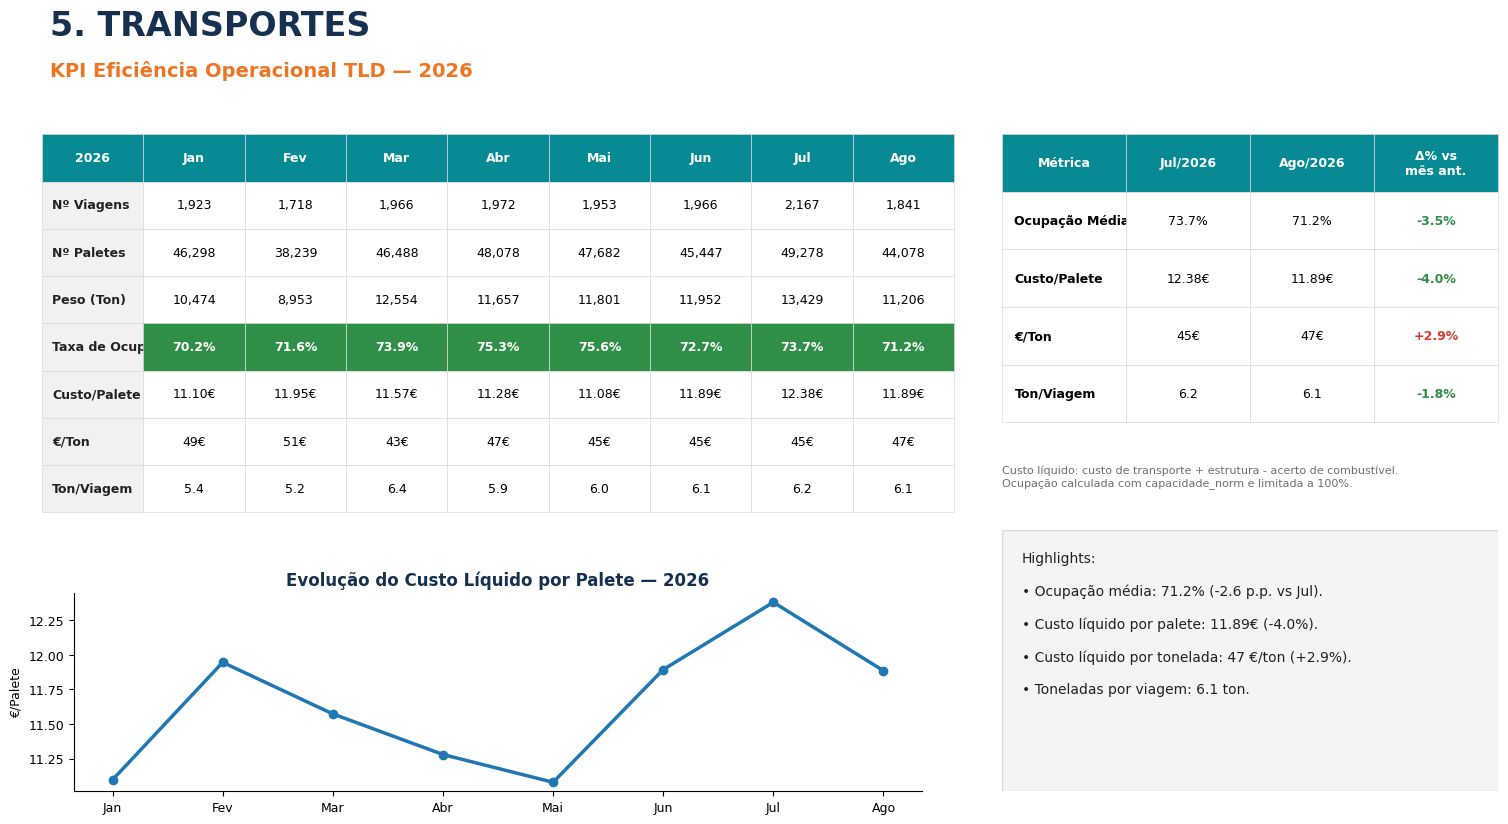

In [39]:
# ==========================
# 1. Imports
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ==========================
# 2. Preparar base 2026
# ==========================
base = df_sel.copy()

for col in [
    "PALETS",
    "PESO_BRUTO",
    "custo_total_c",
    "acerto_combustivel",
    "capacidade_norm",
]:
    base[col] = pd.to_numeric(
        base[col],
        errors="coerce"
    ).fillna(0.0)

fentrega_txt = (
    base["FENTREGA"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

base["data_entrega"] = pd.to_datetime(
    fentrega_txt,
    format="%Y%m%d",
    errors="coerce"
)

mask_data = base["data_entrega"].isna()

base.loc[mask_data, "data_entrega"] = pd.to_datetime(
    fentrega_txt.loc[mask_data],
    errors="coerce"
)

base = base[
    base["data_entrega"].dt.year.eq(2026)
].copy()

base["mes"] = base["data_entrega"].dt.month


# ==========================
# 3. Calcular custo líquido
# ==========================
base["custo_liquido"] = (
    base["custo_total_c"]
    - base["acerto_combustivel"]
)


# ==========================
# 4. Agregar por CODEUT
# ==========================
viagens = (
    base
    .groupby("CODEUT", as_index=False)
    .agg(
        mes=("mes", "first"),
        paletes=("PALETS", "sum"),
        peso_kg=("PESO_BRUTO", "sum"),
        custo_total=("custo_total_c", "sum"),
        combustivel=("acerto_combustivel", "sum"),
        custo_liquido=("custo_liquido", "sum"),
        capacidade=("capacidade_norm", "first"),
    )
)


# ==========================
# 5. Calcular ocupação
# ==========================
viagens["ocupacao_pct"] = (
    viagens["paletes"]
    / viagens["capacidade"]
    * 100
)

viagens.loc[
    viagens["capacidade"].isna()
    | viagens["capacidade"].le(0),
    "ocupacao_pct"
] = np.nan

viagens["ocupacao_pct"] = (
    viagens["ocupacao_pct"]
    .clip(upper=100)
)

viagens["paletes_ocupacao"] = np.minimum(
    viagens["paletes"],
    viagens["capacidade"]
)

viagens.loc[
    viagens["capacidade"].isna()
    | viagens["capacidade"].le(0),
    "paletes_ocupacao"
] = np.nan


# ==========================
# 6. KPI mensal 2026
# ==========================
kpi = (
    viagens
    .groupby("mes", as_index=False)
    .agg(
        viagens=("CODEUT", "nunique"),
        paletes=("paletes", "sum"),
        peso_kg=("peso_kg", "sum"),
        custo_total=("custo_total", "sum"),
        combustivel=("combustivel", "sum"),
        custo_liquido=("custo_liquido", "sum"),
        paletes_ocupacao=("paletes_ocupacao", "sum"),
        capacidade=("capacidade", "sum"),
    )
)

kpi["peso_ton"] = (
    kpi["peso_kg"] / 1000
)

kpi["ocupacao_pct"] = (
    kpi["paletes_ocupacao"]
    / kpi["capacidade"]
    * 100
)

kpi["custo_palete"] = (
    kpi["custo_liquido"]
    / kpi["paletes"].replace(0, np.nan)
)

kpi["eur_ton"] = (
    kpi["custo_liquido"]
    / kpi["peso_ton"].replace(0, np.nan)
)

kpi["ton_viagem"] = (
    kpi["peso_ton"]
    / kpi["viagens"].replace(0, np.nan)
)


# ==========================
# 7. Nomes dos meses
# ==========================
meses = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez",
}

kpi["mes_nome"] = (
    kpi["mes"].map(meses)
)

kpi = (
    kpi
    .sort_values("mes")
    .reset_index(drop=True)
)


# ==========================
# 8. Preparar tabela
# ==========================
metricas = [
    ("Nº Viagens", "viagens"),
    ("Nº Paletes", "paletes"),
    ("Peso (Ton)", "peso_ton"),
    ("Taxa de Ocupação", "ocupacao_pct"),
    ("Custo/Palete", "custo_palete"),
    ("€/Ton", "eur_ton"),
    ("Ton/Viagem", "ton_viagem"),
]

dados_tabela = []

for nome, coluna in metricas:
    linha = [nome]

    for _, reg in kpi.iterrows():
        valor = reg[coluna]

        if coluna in [
            "viagens",
            "paletes",
        ]:
            texto = f"{valor:,.0f}"

        elif coluna == "peso_ton":
            texto = f"{valor:,.0f}"

        elif coluna == "ocupacao_pct":
            texto = f"{valor:.1f}%"

        elif coluna == "custo_palete":
            texto = f"{valor:.2f}€"

        elif coluna == "eur_ton":
            texto = f"{valor:.0f}€"

        elif coluna == "ton_viagem":
            texto = f"{valor:.1f}"

        linha.append(texto)

    dados_tabela.append(linha)


# ==========================
# 9. Comparar último mês
# ==========================
ultimo = kpi.iloc[-1]
anterior = kpi.iloc[-2]

metricas_comparacao = [
    ("Ocupação Média", "ocupacao_pct", "%"),
    ("Custo/Palete", "custo_palete", "€"),
    ("€/Ton", "eur_ton", "€"),
    ("Ton/Viagem", "ton_viagem", ""),
]

comparacao = []

for nome, coluna, unidade in metricas_comparacao:
    valor_atual = ultimo[coluna]
    valor_anterior = anterior[coluna]

    variacao = (
        (valor_atual / valor_anterior) - 1
    ) * 100

    if unidade == "%":
        atual_txt = f"{valor_atual:.1f}%"
        anterior_txt = f"{valor_anterior:.1f}%"

    elif coluna == "custo_palete":
        atual_txt = f"{valor_atual:.2f}€"
        anterior_txt = f"{valor_anterior:.2f}€"

    elif coluna == "eur_ton":
        atual_txt = f"{valor_atual:.0f}€"
        anterior_txt = f"{valor_anterior:.0f}€"

    else:
        atual_txt = f"{valor_atual:.1f}"
        anterior_txt = f"{valor_anterior:.1f}"

    comparacao.append([
        nome,
        anterior_txt,
        atual_txt,
        f"{variacao:+.1f}%"
    ])


# ==========================
# 10. Definir cores
# ==========================
NAVY = "#15314F"
TEAL = "#078A94"
ORANGE = "#EE7623"
GREEN = "#2F8F46"
RED = "#D83A2E"
GREY = "#6E6E6E"
LIGHT_GREY = "#F1F1F1"
MID_GREY = "#D9D9D9"
WHITE = "#FFFFFF"
BLACK = "#222222"


# ==========================
# 11. Criar figura
# ==========================
fig = plt.figure(
    figsize=(16, 9),
    facecolor="white"
)

fig.text(
    0.055,
    0.93,
    "5. TRANSPORTES",
    fontsize=24,
    fontweight="bold",
    color=NAVY
)

fig.text(
    0.055,
    0.885,
    "KPI Eficiência Operacional TLD — 2026",
    fontsize=14,
    fontweight="bold",
    color=ORANGE
)


# ==========================
# 12. Tabela mensal
# ==========================
ax_tabela = fig.add_axes([
    0.05,
    0.40,
    0.57,
    0.42
])

ax_tabela.axis("off")

colunas = [
    "2026"
] + kpi["mes_nome"].tolist()

tabela = ax_tabela.table(
    cellText=dados_tabela,
    colLabels=colunas,
    cellLoc="center",
    colLoc="center",
    loc="upper left",
    bbox=[0, 0, 1, 1]
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)

for (row, col), cell in tabela.get_celld().items():
    cell.set_linewidth(0.5)
    cell.set_edgecolor(MID_GREY)

    if row == 0:
        cell.set_facecolor(TEAL)
        cell.set_text_props(
            color=WHITE,
            fontweight="bold"
        )

    elif col == 0:
        cell.set_facecolor(LIGHT_GREY)
        cell.set_text_props(
            color=BLACK,
            fontweight="bold",
            ha="left"
        )

    else:
        cell.set_facecolor(WHITE)


# ==========================
# 13. Destacar ocupação
# ==========================
linha_ocupacao = 4

for col in range(
    1,
    len(colunas)
):
    tabela[
        linha_ocupacao,
        col
    ].set_facecolor(GREEN)

    tabela[
        linha_ocupacao,
        col
    ].set_text_props(
        color=WHITE,
        fontweight="bold"
    )


# ==========================
# 14. Quadro comparação
# ==========================
ax_comp = fig.add_axes([
    0.65,
    0.50,
    0.31,
    0.32
])

ax_comp.axis("off")

colunas_comp = [
    "Métrica",
    f"{anterior['mes_nome']}/2026",
    f"{ultimo['mes_nome']}/2026",
    "Δ% vs\nmês ant."
]

tabela_comp = ax_comp.table(
    cellText=comparacao,
    colLabels=colunas_comp,
    cellLoc="center",
    colLoc="center",
    loc="upper left",
    bbox=[0, 0, 1, 1]
)

tabela_comp.auto_set_font_size(False)
tabela_comp.set_fontsize(9)

for (row, col), cell in tabela_comp.get_celld().items():
    cell.set_linewidth(0.5)
    cell.set_edgecolor(MID_GREY)

    if row == 0:
        cell.set_facecolor(TEAL)
        cell.set_text_props(
            color=WHITE,
            fontweight="bold"
        )

    elif col == 0:
        cell.set_text_props(
            fontweight="bold",
            ha="left"
        )

for i, reg in enumerate(
    comparacao,
    start=1
):
    variacao = float(
        reg[3]
        .replace("%", "")
        .replace("+", "")
    )

    tabela_comp[
        i,
        3
    ].set_text_props(
        color=RED if variacao > 0 else GREEN,
        fontweight="bold"
    )


# ==========================
# 15. Gráfico Custo/Palete
# ==========================
ax_grafico = fig.add_axes([
    0.07,
    0.09,
    0.53,
    0.22
])

ax_grafico.plot(
    kpi["mes_nome"],
    kpi["custo_palete"],
    marker="o",
    linewidth=2.5
)

ax_grafico.set_title(
    "Evolução do Custo Líquido por Palete — 2026",
    fontsize=12,
    fontweight="bold",
    color=NAVY
)

ax_grafico.set_ylabel(
    "€/Palete",
    fontsize=9
)

ax_grafico.spines[
    ["top", "right"]
].set_visible(False)

ax_grafico.tick_params(
    axis="both",
    labelsize=9
)

ax_grafico.grid(False)


# ==========================
# 16. Highlights
# ==========================
delta_ocupacao = (
    ultimo["ocupacao_pct"]
    - anterior["ocupacao_pct"]
)

delta_custo_palete = (
    (
        ultimo["custo_palete"]
        / anterior["custo_palete"]
    ) - 1
) * 100

delta_eur_ton = (
    (
        ultimo["eur_ton"]
        / anterior["eur_ton"]
    ) - 1
) * 100

texto_highlights = (
    "Highlights:\n\n"
    f"• Ocupação média: "
    f"{ultimo['ocupacao_pct']:.1f}% "
    f"({delta_ocupacao:+.1f} p.p. vs "
    f"{anterior['mes_nome']}).\n\n"
    f"• Custo líquido por palete: "
    f"{ultimo['custo_palete']:.2f}€ "
    f"({delta_custo_palete:+.1f}%).\n\n"
    f"• Custo líquido por tonelada: "
    f"{ultimo['eur_ton']:.0f} €/ton "
    f"({delta_eur_ton:+.1f}%).\n\n"
    f"• Toneladas por viagem: "
    f"{ultimo['ton_viagem']:.1f} ton."
)


# ==========================
# 17. Caixa highlights
# ==========================
ax_high = fig.add_axes([
    0.65,
    0.09,
    0.31,
    0.29
])

ax_high.axis("off")

rect = Rectangle(
    (0, 0),
    1,
    1,
    transform=ax_high.transAxes,
    facecolor="#F4F4F4",
    edgecolor=MID_GREY,
    linewidth=1
)

ax_high.add_patch(rect)

ax_high.text(
    0.04,
    0.92,
    texto_highlights,
    transform=ax_high.transAxes,
    va="top",
    fontsize=10,
    color=BLACK
)


# ==========================
# 18. Nota metodológica
# ==========================
fig.text(
    0.65,
    0.43,
    (
        "Custo líquido: custo de transporte + estrutura "
        "- acerto de combustível.\n"
        "Ocupação calculada com capacidade_norm "
        "e limitada a 100%."
    ),
    fontsize=8,
    color=GREY
)


# ==========================
# 19. Mostrar gráfico
# ==========================
plt.show()